<html>
  <body>
    <header></header>
        <CENTER>
          <img src="https://professor.uvv.br/Content/img/logo-uvv.png" alt="UVV-LOGO" style = width="100px"; height="100px">
        </CENTER>
        <CENTER><b>DATA SCIENCE PROJECT</b></CENTER><br/>
        <CENTER><b>WORKFLOW PARTE 1 DO PROJETO</b></CENTER><br/>

NOME COMPLETO: LENON OTMAR TONOLI MERLO

LINK PARA SEU PRÓPRIO COLAB: [Link](sp=sharing)

LINK PARA SEU PRÓPRIO GITHUB: [Aqui](https://)

LINK PARA SEU VÍDEO NO YOUTUBE: [Aqui](https://)

<center>

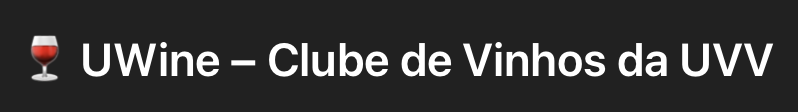

<center>

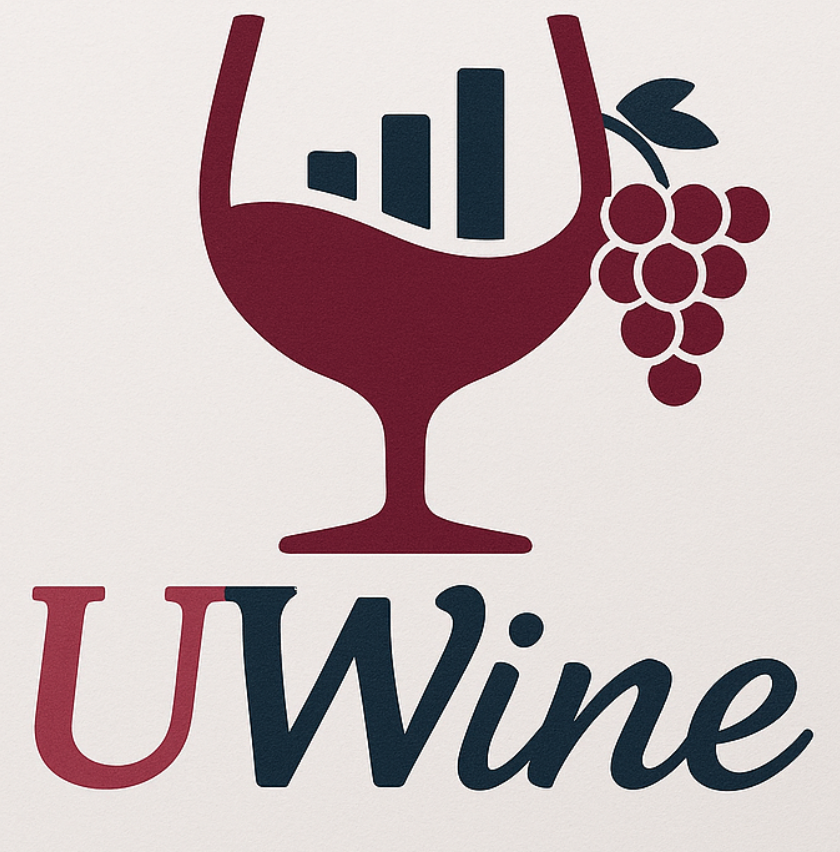

# **Cenário Fictício**:

Prezados(as) alunos(as),

É com entusiasmo que apresento a proposta do **Projeto de Conclusão de Curso (TCC)** para os estudantes do curso de Ciência de Dados da Universidade Vila Velha: o UWine – Clube de Vinhos da UVV.

A proposta do projeto consiste na análise de um Clube de Vinhos universitário fictício, com base em dados simulados, que será totalmente orientado por técnicas e práticas de Ciência de Dados.

Sendo assim, você foi designado como **Consultor em Ciência de Dados** ( ***Data Science Consultant*** ) para fazer uma análise completa dos dados dos clientes a partir de um conjunto de dados (Amostra) com mais de 1 milhão de notas fiscais (~ 350 Megabytes). Além disso, há uma entrada diária de aproximadamente umas 5000 novas notas fiscais no sistema.

O objetivo é permitir que cada consultor(a) percorra foco analíticos diferentes dentro do mesmo ecossistema de dados, aplicando modelos de machine learning supervisionado ou não supervisionado, análise preditiva, dashboards interativos, entre outros.

Para garantir organização, profundidade técnica e coerência metodológica no desenvolvimento do ***Projeto UWine***, adotaremos um workflow composto por cinco etapas principais, alinhadas às boas práticas da Ciência de Dados. Cada etapa representa um marco do processo analítico, permitindo que cada analista avance de forma estruturada do entendimento inicial dos dados até a entrega final dos insights.

# BIBLIOTECAS E FUNÇÕES E CÓDIGOS

In [1]:
# Imports

import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import shapiro, chi2_contingency, f_oneway, ttest_ind, levene
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

In [2]:
CAMINHO_DADOS = "/content/table25.csv"

table = pd.read_csv(CAMINHO_DADOS, index_col=0)

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

n_linhas, n_colunas = table.shape

print("TCC - UVVine: Análise Estatística de Amostragem")
print(f"Base carregada com {n_linhas:,} registros e {n_colunas} variáveis.")


TCC - UVVine: Análise Estatística de Amostragem
Base carregada com 1,120,000 registros e 23 variáveis.


In [3]:
display(table.head())

n_linhas, n_colunas = table.shape
print(f"Dimensão da base: {n_linhas:,} linhas e {n_colunas} colunas.")

table.info()

valores_nulos = table.isna().sum().sort_values(ascending=False)
valores_nulos = valores_nulos[valores_nulos > 0]

if len(valores_nulos) > 0:
    display(valores_nulos)
else:
    print("Não foram identificados valores ausentes na base de dados.")

,NOTA FISCAL,REGIÃO,SEXO,ESTADO CIVIL,DEPENDENTES,RENDA BRUTO (R$),OPINIÃO DO CLIENTE,NOTA DE SATISFAÇÃO (%),MEAN: alcohol,MEAN: malic_acid,...,MEAN: total_phenols,MEAN: flavanoids,MEAN: nonflavanoid_phenols,MEAN: proanthocyanins,MEAN: color_intensity,MEAN: hue,MEAN: od280/od315_of_diluted_wines,MEAN: proline,TIPO DA CONTA,TOTAL (R$)
0,5836177,SUDESTE,MASCULINO,CASADO,1,8012.27,Gostei do atendimento prestado pela UVVine,68.680,14.044677,1.484295,...,2.919873,1.898048,0.455349,1.917438,4.139711,0.934844,1.961535,955.701693,VIP,1043.59
1,1981138,SUDESTE,MASCULINO,SOLTEIRO,1,21897.71,"Nada demais, serviço regular na UVVine",69.589,11.738318,0.930835,...,2.763588,1.048772,0.220046,1.589010,2.859220,0.766190,2.315932,680.732234,PRIME,1315.85
2,6293910,SUDESTE,MASCULINO,DESQUITADO(A) / VIÚVO(A),0,19840.24,Foi indiferente minha experiência com a UVVine,68.680,12.241004,2.756235,...,2.580669,0.981184,0.355254,1.591051,6.238933,0.844660,3.868414,659.935656,PRIME,1390.81
3,5656569,SUDESTE,MASCULINO,SOLTEIRO,1,3167.32,Gostei do atendimento prestado pela UVVine,68.680,12.905167,3.585136,...,2.489790,1.418967,0.303763,1.788616,2.404009,1.086255,3.854773,718.578770,ESSENTIAL,223.70
4,8642826,NORDESTE,FEMININO,CASADO,1,9061.20,Fiquei satisfeito com o serviço da UVVine,70.397,12.550841,4.746782,...,4.464296,2.827265,0.341251,0.625414,2.856048,1.183745,2.444532,498.733620,PRIME,1451.78


Dimensão da base: 1,120,000 linhas e 23 colunas.
<class 'pandas.core.frame.DataFrame'>
Index: 1120000 entries, 0 to 1119999
Data columns (total 23 columns):
 #   Column                              Non-Null Count    Dtype  
---  ------                              --------------    -----  
 0   NOTA FISCAL                         1120000 non-null  int64  
 1   REGIÃO                              1120000 non-null  object 
 2   SEXO                                1120000 non-null  object 
 3   ESTADO CIVIL                        1120000 non-null  object 
 4   DEPENDENTES                         1120000 non-null  int64  
 5   RENDA BRUTO (R$)                    1120000 non-null  float64
 6   OPINIÃO DO CLIENTE                  1120000 non-null  object 
 7   NOTA DE SATISFAÇÃO (%)              1120000 non-null  float64
 8   MEAN: alcohol                       1120000 non-null  float64
 9   MEAN: malic_acid                    1120000 non-null  float64
 10  MEAN: ash                         

In [4]:
qualitativas = ["REGIÃO", "SEXO", "ESTADO CIVIL", "OPINIÃO DO CLIENTE", "TIPO DA CONTA"]

quantitativas = [
    "DEPENDENTES",
    "RENDA BRUTO (R$)",
    "NOTA DE SATISFAÇÃO (%)",
    "TOTAL (R$)",
    "MEAN: alcohol",
    "MEAN: malic_acid",
    "MEAN: ash",
    "MEAN: alcalinity_of_ash",
    "MEAN: magnesium",
    "MEAN: total_phenols",
    "MEAN: flavanoids",
    "MEAN: nonflavanoid_phenols",
    "MEAN: proanthocyanins",
    "MEAN: color_intensity",
    "MEAN: hue",
    "MEAN: od280/od315_of_diluted_wines",
    "MEAN: proline",
]

In [5]:
RESULTADOS = {}

def calcular_tamanho_amostra_proporcao(N, z=1.96, p=0.5, e=0.05):
    """Calcula o tamanho mínimo da amostra para população finita e infinita."""
    numerador = (z ** 2) * p * (1 - p)
    denominador = e ** 2
    n = numerador / denominador

    n_ajustado = n / (1 + (n / N))
    return int(np.ceil(n)), int(np.ceil(n_ajustado))

In [6]:
# Paleta padrão dos gráficos
PLOT_COLORS = {
    "main_line": "tab:blue",
    "ref_line": "tab:orange",
    "ideal_pt": "tab:green",
    "zero": "tab:red",
    "ci": "tab:purple",
    "li": "tab:red",
    "ls": "tab:purple",
    "hist": "tab:blue",
    "kde": "tab:orange",
}

# Workflow: Detalhamento das Atividades

##Atividade A1 ([Link](https://colab.research.google.com/drive/1w-72bl_qBnGIR8y9zcGYNcpar9b2JdwA?usp=sharing)): Estratificação amostral da população


Nesta etapa, busca-se determinar o tamanho ideal da amostra para representar adequadamente a população disponível, considerando nível de confiança e margem de erro.

Também são avaliadas características da distribuição dos dados (outliers e testes estatísticos), garantindo base metodológica sólida para as próximas análises.


### Atividade A1.1: Determinação do tamanho da amostra

Nesta etapa, o tamanho ideal da amostra é definido com base na estabilização do erro-padrão da média da variável `TOTAL (R$)`. Para isso, são simulados diferentes tamanhos amostrais, identificando-se o menor tamanho `n` para o qual o erro-padrão estimado é menor ou igual ao erro-padrão médio.


In [7]:
def AtividadeA1_1():
    y = table["TOTAL (R$)"].dropna()
    N = len(y)

    tamanhos = np.arange(100, 200_100, 100)
    erros_padrao = np.zeros(len(tamanhos), dtype=float)

    rng = np.random.default_rng(42)
    R_pequeno = 15
    R_grande = 3

    for idx, n in enumerate(tamanhos):
        R = R_pequeno if n <= 50_000 else R_grande
        se_rep = []

        for _ in range(R):
            seed = int(rng.integers(0, 1_000_000_000))
            amostra = y.sample(n=n, replace=False, random_state=seed)
            se_rep.append(amostra.std(ddof=1) / np.sqrt(n))

        erros_padrao[idx] = np.mean(se_rep)

    se_medio = float(erros_padrao.mean())
    media_total = float(y.mean())

    ic_inf = media_total - 1.96 * se_medio
    ic_sup = media_total + 1.96 * se_medio

    idx_ideal = int(np.where(erros_padrao <= se_medio)[0][0])
    n_ideal = int(tamanhos[idx_ideal])
    se_ideal = float(erros_padrao[idx_ideal])

    RESULTADOS["A1.1"] = {
        "N": int(N),
        "media_total": media_total,
        "se_medio": se_medio,
        "ic_95": (float(ic_inf), float(ic_sup)),
        "tamanho_ideal": n_ideal,
        "tamanhos": tamanhos,
        "erros_padrao": erros_padrao,
        "se_ideal": se_ideal,
    }

    print(f"População disponível (N): {N:,}")
    print(f"Média de TOTAL (R$): {media_total:.2f}")
    print(f"Erro-padrão-médio: {se_medio:.6f}")
    print(f"IC 95% da média: [{ic_inf:.2f}, {ic_sup:.2f}]")
    print(f"Tamanho ideal da amostra: {n_ideal:,}")


In [8]:
AtividadeA1_1()
resultado = RESULTADOS["A1.1"]

População disponível (N): 1,120,000
Média de TOTAL (R$): 851.19
Erro-padrão-médio: 3.751394
IC 95% da média: [843.83, 858.54]
Tamanho ideal da amostra: 51,400


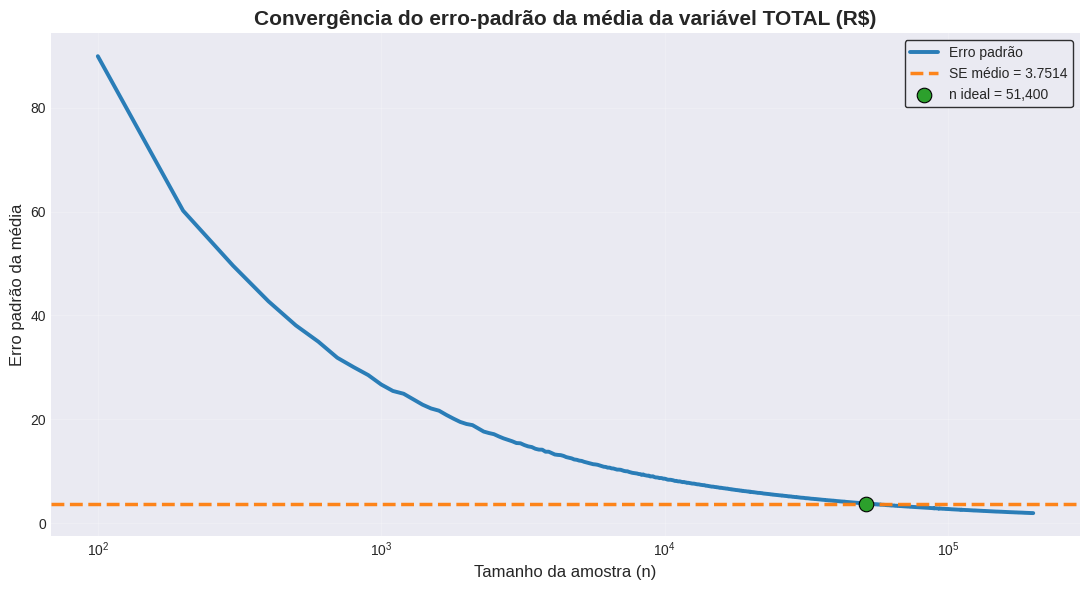

In [9]:
plt.figure(figsize=(11, 6))
plt.plot(
    resultado["tamanhos"],
    resultado["erros_padrao"],
    color=PLOT_COLORS["main_line"],
    linewidth=2.8,
    alpha=0.95,
    label="Erro padrão",
)
plt.axhline(
    resultado["se_medio"],
    color=PLOT_COLORS["ref_line"],
    linestyle="--",
    linewidth=2.5,
    alpha=0.95,
    label=f'SE médio = {resultado["se_medio"]:.4f}',
)
plt.scatter(
    resultado["tamanho_ideal"],
    resultado["se_ideal"],
    color=PLOT_COLORS["ideal_pt"],
    s=110,
    zorder=6,
    edgecolor="black",
    linewidth=0.8,
    label=f'n ideal = {resultado["tamanho_ideal"]:,}',
)
plt.title("Convergência do erro-padrão da média da variável TOTAL (R$)", fontsize=15, fontweight="bold")
plt.xlabel("Tamanho da amostra (n)", fontsize=12)
plt.xscale("log")
plt.ylabel("Erro padrão da média", fontsize=12)
plt.grid(alpha=0.22)
plt.legend(frameon=True, edgecolor="black")
plt.tight_layout()
sns.despine()
plt.show()


Os resultados evidenciam que o erro-padrão da média decresce conforme o tamanho amostral aumenta, apresentando estabilização progressiva ao longo das simulações. Considerando o critério `SE(n) <= SE médio`, o tamanho ideal da amostra foi estabelecido em `n = 51.400`, sendo este o valor adotado nas etapas posteriores do estudo.


### Atividade A1.2: Análise dos outliers

Nesta etapa, realiza-se a análise da variável `NOTA DE SATISFAÇÃO (%)` com o objetivo de identificar concentração excessiva de valores, possíveis outliers e o comportamento geral da distribuição.


In [11]:
serie = table["NOTA DE SATISFAÇÃO (%)"]

resumo = serie.describe().to_frame(name="Valor")
frequencias = serie.value_counts().head(10).to_frame(name="Frequência")
proporcoes = (serie.value_counts(normalize=True).head(10) * 100).to_frame(name="Percentual (%)")

display(resumo)
print(f"Quantidade de valores únicos: {serie.nunique():,}")
display(frequencias)
display(proporcoes.round(3))

,Valor
count,1.120000e+06
mean,6.896948e+01
std,1.356640e+00
min,6.868000e+01
25%,6.868000e+01
50%,6.868000e+01
75%,6.868000e+01
max,9.211200e+01


Quantidade de valores únicos: 202


,Frequência
NOTA DE SATISFAÇÃO (%),
68.680,1042915
69.185,1306
68.882,1306
69.084,1260
68.983,1236
70.094,1234
69.589,1226
69.387,1225
69.690,1207


,Percentual (%)
NOTA DE SATISFAÇÃO (%),
68.680,93.117
69.185,0.117
68.882,0.117
69.084,0.112
68.983,0.110
70.094,0.110
69.589,0.109
69.387,0.109
69.690,0.108


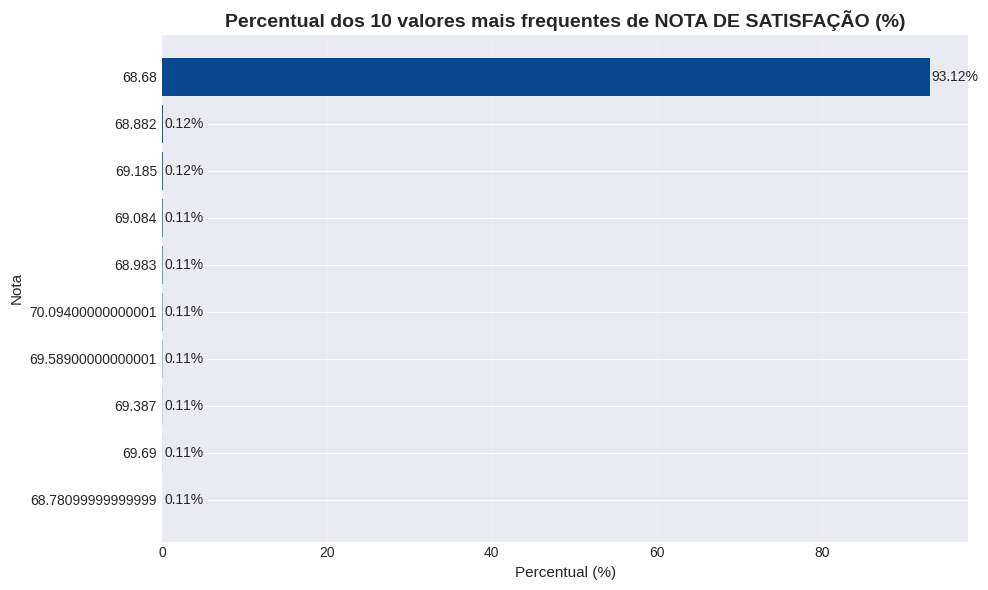

In [13]:
top_valores = (serie.value_counts(normalize=True).head(10) * 100).sort_values()

plt.figure(figsize=(10, 6))
bars = plt.barh(
    top_valores.index.astype(str),
    top_valores.values,
    color=sns.color_palette("Blues", len(top_valores))
)

plt.title("Percentual dos 10 valores mais frequentes de NOTA DE SATISFAÇÃO (%)", fontsize=14, fontweight="bold")
plt.xlabel("Percentual (%)", fontsize=11)
plt.ylabel("Nota", fontsize=11)
plt.grid(axis="x", alpha=0.20)

for bar in bars:
    largura = bar.get_width()
    plt.text(largura + 0.2, bar.get_y() + bar.get_height() / 2, f"{largura:.2f}%", va="center", fontsize=10)

plt.tight_layout()
sns.despine()
plt.show()


In [14]:
# Funções auxiliaras

def identificar_outliers_iqr(dados, coluna):
    serie = dados[coluna].dropna()

    q1 = float(serie.quantile(0.25))
    q3 = float(serie.quantile(0.75))
    iqr = float(q3 - q1)

    li = float(q1 - 1.5 * iqr)
    ls = float(q3 + 1.5 * iqr)

    outliers = dados[(dados[coluna] < li) | (dados[coluna] > ls)]

    return {
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "li": li,
        "ls": ls,
        "qtd_outliers": int(len(outliers)),
    }


def winsorizar_por_limites(dados, coluna, li, ls):
    return dados[coluna].clip(lower=li, upper=ls)


In [15]:
# Execução da análise

def AtividadeA1_2():
    variaveis = ["RENDA BRUTO (R$)", "NOTA DE SATISFAÇÃO (%)", "TOTAL (R$)"]
    n_registros = len(table)

    resumo = []
    limites = {}
    table_wins = table.copy()
    impacto = []

    for var in variaveis:
        info = identificar_outliers_iqr(table, var)
        perc_outliers = (info["qtd_outliers"] / n_registros) * 100

        diagnostico = (
            "IQR adequado"
            if info["iqr"] > 0
            else "IQR = 0; usar apenas para diagnóstico"
        )

        resumo.append({
            "Variável": var,
            "Q1": info["q1"],
            "Q3": info["q3"],
            "IQR": info["iqr"],
            "LI": info["li"],
            "LS": info["ls"],
            "Qtd. Outliers": info["qtd_outliers"],
            "% Outliers": perc_outliers,
            "Diagnóstico": diagnostico,
        })

        limites[var] = info

        media_antes = float(table[var].mean())
        dp_antes = float(table[var].std())

        if info["iqr"] > 0:
            table_wins[var] = winsorizar_por_limites(table, var, info["li"], info["ls"])
            media_depois = float(table_wins[var].mean())
            dp_depois = float(table_wins[var].std())
            acao = "Winsorizada"
        else:
            media_depois = media_antes
            dp_depois = dp_antes
            acao = "Mantida"

        impacto.append({
            "Variável": var,
            "Ação": acao,
            "Média antes": media_antes,
            "Média depois": media_depois,
            "DP antes": dp_antes,
            "DP depois": dp_depois,
        })

    resumo_df = pd.DataFrame(resumo).sort_values("% Outliers", ascending=False)
    impacto_df = pd.DataFrame(impacto)

    RESULTADOS["A1.2"] = {
        "resumo": resumo_df,
        "impacto_winsorizacao": impacto_df,
        "limites_iqr": limites,
        "table_wins": table_wins,
    }

    print("Análise de outliers concluída.")
    print(f"Variáveis analisadas: {len(variaveis)}")
    print(f"Maior percentual de outliers: {resumo_df.iloc[0]['Variável']} ({resumo_df.iloc[0]['% Outliers']:.2f}%)")

In [16]:
# Execução e tabelas

AtividadeA1_2()

resultado = RESULTADOS["A1.2"]

resumo_exibicao = resultado["resumo"].copy()
resumo_exibicao[["Q1", "Q3", "IQR", "LI", "LS", "% Outliers"]] = (
    resumo_exibicao[["Q1", "Q3", "IQR", "LI", "LS", "% Outliers"]].round(2)
)

impacto_exibicao = resultado["impacto_winsorizacao"].copy()
impacto_exibicao[["Média antes", "Média depois", "DP antes", "DP depois"]] = (
    impacto_exibicao[["Média antes", "Média depois", "DP antes", "DP depois"]].round(2)
)

display(resumo_exibicao)
display(impacto_exibicao)


Análise de outliers concluída.
Variáveis analisadas: 3
Maior percentual de outliers: RENDA BRUTO (R$) (17.39%)


,Variável,Q1,Q3,IQR,LI,LS,Qtd. Outliers,% Outliers,Diagnóstico
0,RENDA BRUTO (R$),3240.67,8069.25,4828.58,-4002.20,15312.13,194771,17.39,IQR adequado
2,TOTAL (R$),323.92,1068.84,744.92,-793.46,2186.22,106903,9.54,IQR adequado
1,NOTA DE SATISFAÇÃO (%),68.68,68.68,0.00,68.68,68.68,77085,6.88,IQR = 0; usar apenas para diagnóstico


,Variável,Ação,Média antes,Média depois,DP antes,DP depois
0,RENDA BRUTO (R$),Winsorizada,7722.33,6737.46,6639.55,4613.48
1,NOTA DE SATISFAÇÃO (%),Mantida,68.97,68.97,1.36,1.36
2,TOTAL (R$),Winsorizada,851.19,768.82,852.08,628.37


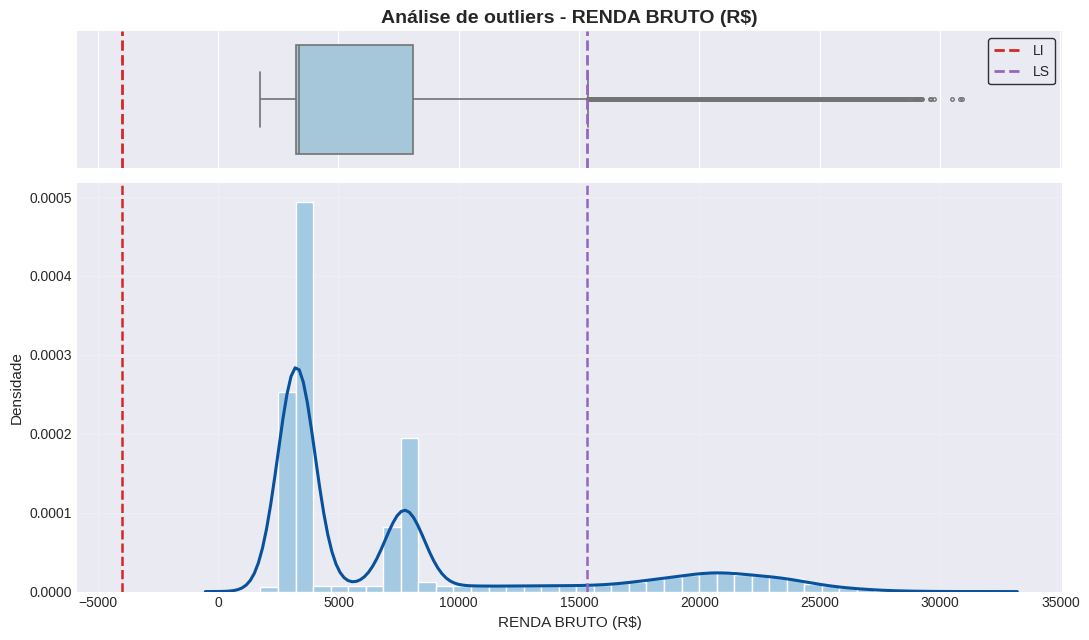

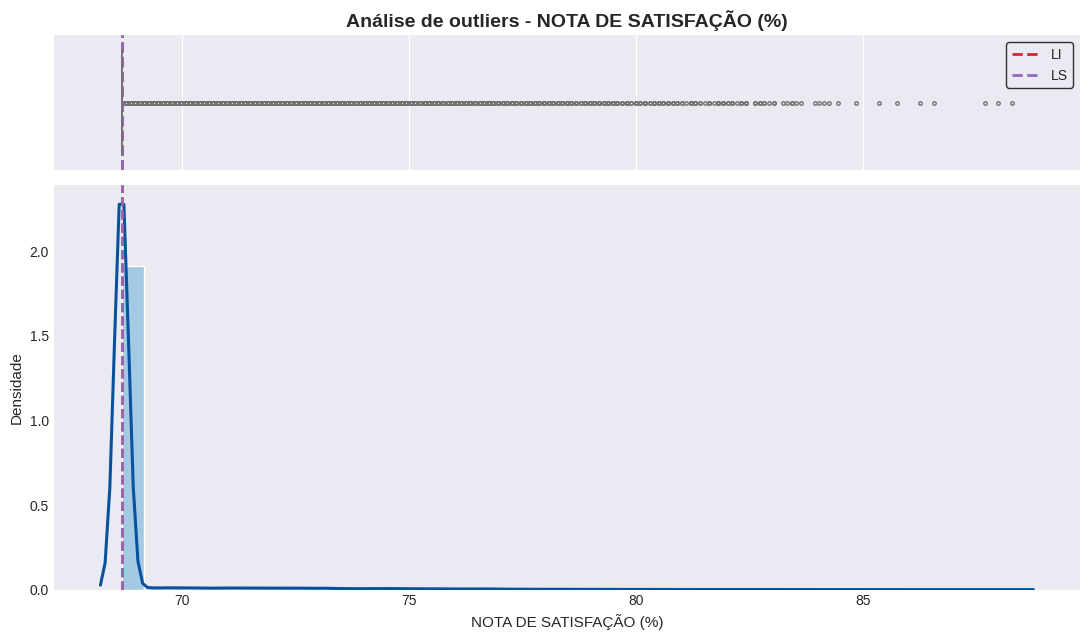

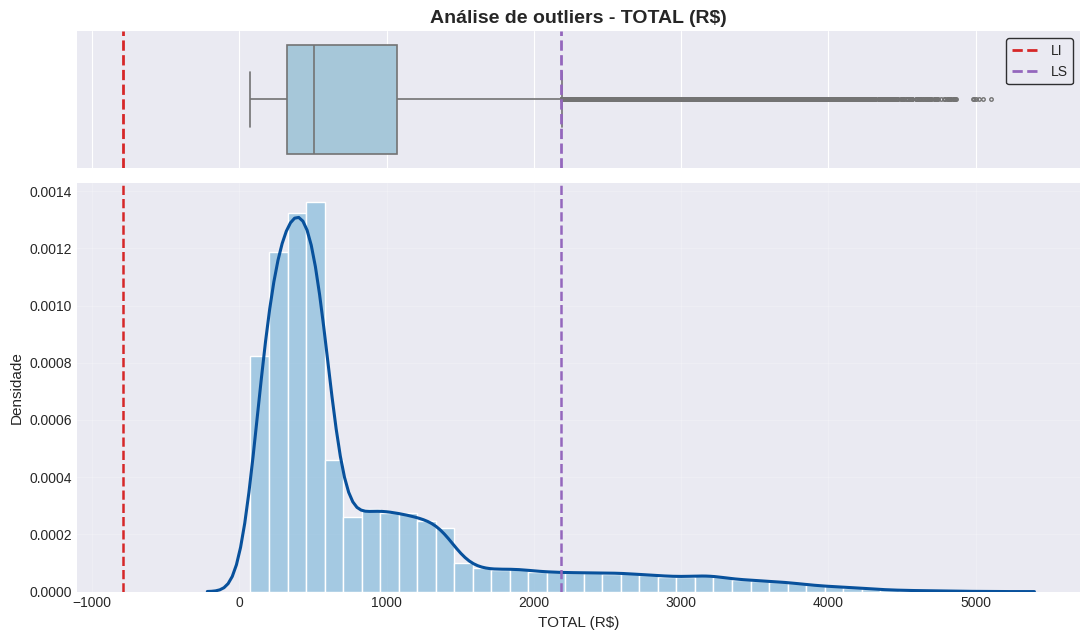

In [17]:
# Gráficos

df_plot = table[["RENDA BRUTO (R$)", "NOTA DE SATISFAÇÃO (%)", "TOTAL (R$)"]].dropna().sample(
    n=min(50000, len(table)),
    random_state=42
)

for var in df_plot.columns:
    info = resultado["limites_iqr"][var]

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(11, 6.5),
        gridspec_kw={"height_ratios": [1, 3]},
        sharex=True
    )

    sns.boxplot(
        x=df_plot[var],
        color="#9ecae1",
        linewidth=1.2,
        fliersize=2.5,
        ax=axes[0]
    )

    axes[0].axvline(info["li"], color="#d62728", linestyle="--", linewidth=2, label="LI")
    axes[0].axvline(info["ls"], color="#9467bd", linestyle="--", linewidth=2, label="LS")
    axes[0].set_title(f"Análise de outliers - {var}", fontsize=14, fontweight="bold")
    axes[0].set_ylabel("")
    axes[0].legend(frameon=True, edgecolor="black")

    sns.histplot(
        df_plot[var],
        bins=40,
        stat="density",
        color="#6baed6",
        edgecolor="white",
        alpha=0.55,
        ax=axes[1]
    )

    sns.kdeplot(
        df_plot[var],
        color="#08519c",
        linewidth=2.2,
        ax=axes[1]
    )

    axes[1].axvline(info["li"], color="#d62728", linestyle="--", linewidth=1.8)
    axes[1].axvline(info["ls"], color="#9467bd", linestyle="--", linewidth=1.8)
    axes[1].set_xlabel(var, fontsize=11)
    axes[1].set_ylabel("Densidade", fontsize=11)
    axes[1].grid(alpha=0.20)

    plt.tight_layout()
    sns.despine()
    plt.show()


A análise de outliers pelo método IQR identificou valores extremos nas variáveis `RENDA BRUTO (R$)` e `TOTAL (R$)`, com maior incidência em `RENDA BRUTO (R$)` (`17,39%`). Ambas apresentaram assimetria à direita, justificando a criação de uma versão winsorizada para análises comparativas e maior robustez estatística.

Já a variável `NOTA DE SATISFAÇÃO (%)` apresentou forte concentração em torno de `68,68`, resultando em `IQR = 0`. Nesse caso, o método IQR mostrou-se inadequado para tratamento de outliers, razão pela qual essa variável foi mantida apenas para fins descritivos, sem winsorização.

Assim, a estratégia adotada foi manter a base original e utilizar a versão winsorizada apenas nas variáveis em que o procedimento se mostrou metodologicamente apropriado.


###Atividade A1.3: Testes de Hipóteses ([Link](https://colab.research.google.com/drive/1_YGamH-qOWSNaCKG5kVlLiZPuXv5lT34?usp=sharing))

Nesta etapa, avalia-se se a amostra ideal obtida na Atividade A1.1 representa adequadamente a população para a variável `TOTAL (R$)`. Para isso, são realizados o diagnóstico de normalidade, o teste de hipótese para comparação entre média amostral e média populacional, a validação por bootstrap e a análise do impacto da winsorização sobre os resultados.


In [18]:
def AtividadeA1_3():
    alpha = 0.05
    z_95 = 1.96
    B = 3000
    y_col = "TOTAL (R$)"

    if "A1.1" not in RESULTADOS or "tamanho_ideal" not in RESULTADOS["A1.1"]:
        raise ValueError("Execute a Atividade A1.1 antes desta etapa.")

    n_ideal = int(RESULTADOS["A1.1"]["tamanho_ideal"])

    y_full = table[y_col].dropna()
    N = len(y_full)

    mu_pop = float(y_full.mean())
    sd_pop = float(y_full.std(ddof=1))
    se_pop = sd_pop / np.sqrt(N)

    n_norm = min(5000, N)
    y_norm = y_full.sample(n=n_norm, random_state=42)

    sh_stat, sh_p = shapiro(y_norm)
    decisao_normalidade = "Rejeita normalidade" if sh_p <= alpha else "Não rejeita normalidade"

    y_sample = y_full.sample(n=n_ideal, random_state=123)
    mu_s = float(y_sample.mean())
    sd_s = float(y_sample.std(ddof=1))
    se_s = sd_s / np.sqrt(n_ideal)

    z_stat = (mu_s - mu_pop) / se_s if se_s > 0 else np.nan
    p_val = 2 * (1 - stats.norm.cdf(abs(z_stat))) if np.isfinite(z_stat) else np.nan
    decisao_teste = "Não rejeita H0" if p_val > alpha else "Rejeita H0"

    ic_inf = mu_s - z_95 * se_s
    ic_sup = mu_s + z_95 * se_s

    rng = np.random.default_rng(42)
    y_vals = y_sample.values
    n = len(y_vals)

    boot_means = np.empty(B, dtype=float)
    for b in range(B):
        idx = rng.integers(0, n, size=n)
        boot_means[b] = y_vals[idx].mean()

    ci_b_inf = float(np.percentile(boot_means, 2.5))
    ci_b_sup = float(np.percentile(boot_means, 97.5))

    diff_obs = mu_s - mu_pop
    boot_diff = boot_means - mu_pop
    ci_d_inf = float(np.percentile(boot_diff, 2.5))
    ci_d_sup = float(np.percentile(boot_diff, 97.5))

    p_boot = 2 * min((boot_diff <= 0).mean(), (boot_diff >= 0).mean())
    p_boot = float(min(1.0, p_boot))

    impacto_outliers = None

    if "A1.2" in RESULTADOS and "limites_iqr" in RESULTADOS["A1.2"]:
        limites_total = RESULTADOS["A1.2"]["limites_iqr"].get(y_col)

        if limites_total:
            li = limites_total["li"]
            ls = limites_total["ls"]

            y_wins = winsorizar_por_limites(table, y_col, li, ls)

            idx_sample = y_sample.index
            y_orig = y_full.loc[idx_sample].values
            y_wins_sample = y_wins.loc[idx_sample].values

            t_stat, p_t = ttest_ind(y_orig, y_wins_sample, equal_var=False)
            diff_ow = float(y_orig.mean() - y_wins_sample.mean())

            boot_dw = np.empty(B, dtype=float)
            for b in range(B):
                idxb = rng.integers(0, n, size=n)
                boot_dw[b] = y_orig[idxb].mean() - y_wins_sample[idxb].mean()

            ci_dw_inf = float(np.percentile(boot_dw, 2.5))
            ci_dw_sup = float(np.percentile(boot_dw, 97.5))

            impacto_outliers = {
                "li": li,
                "ls": ls,
                "media_original": float(y_orig.mean()),
                "media_winsorizada": float(y_wins_sample.mean()),
                "diferenca": diff_ow,
                "p_value_welch": float(p_t),
                "ic95_diff": (ci_dw_inf, ci_dw_sup),
                "boot_diff": boot_dw,
            }

    RESULTADOS["A1.3"] = {
        "variavel": y_col,
        "alpha": alpha,
        "B": B,
        "N": int(N),
        "n_ideal": int(n_ideal),
        "populacao": {
            "media": mu_pop,
            "dp": sd_pop,
            "se": float(se_pop),
        },
        "normalidade": {
            "n_amostra": int(n_norm),
            "shapiro_stat": float(sh_stat),
            "shapiro_p": float(sh_p),
            "decisao": decisao_normalidade,
            "amostra": y_norm,
        },
        "amostra_ideal": {
            "media": mu_s,
            "dp": sd_s,
            "se": float(se_s),
            "ic95": (float(ic_inf), float(ic_sup)),
            "valores": y_sample,
        },
        "teste_media": {
            "z": float(z_stat),
            "p_value": float(p_val),
            "decisao": decisao_teste,
            "diff_obs": float(diff_obs),
        },
        "bootstrap": {
            "medias": boot_means,
            "diffs": boot_diff,
            "ic95_media": (ci_b_inf, ci_b_sup),
            "ic95_diff": (ci_d_inf, ci_d_sup),
            "p_boot": float(p_boot),
        },
        "impacto_outliers": impacto_outliers,
    }

    print("Análise de hipóteses concluída.")
    print(f"Variável analisada: {y_col}")
    print(f"Amostra ideal utilizada: {n_ideal:,}")
    print(f"Teste principal: {decisao_teste} (p = {p_val:.4f})")


In [19]:
AtividadeA1_3()
resultado = RESULTADOS["A1.3"]

Análise de hipóteses concluída.
Variável analisada: TOTAL (R$)
Amostra ideal utilizada: 51,400
Teste principal: Não rejeita H0 (p = 0.5644)


In [20]:
resumo_a13 = pd.DataFrame(
    [
        {
            "Etapa": "Normalidade",
            "Estatística": resultado["normalidade"]["shapiro_stat"],
            "p-valor": resultado["normalidade"]["shapiro_p"],
            "Decisão": resultado["normalidade"]["decisao"],
        },
        {
            "Etapa": "Teste da média",
            "Estatística": resultado["teste_media"]["z"],
            "p-valor": resultado["teste_media"]["p_value"],
            "Decisão": resultado["teste_media"]["decisao"],
        },
        {
            "Etapa": "Bootstrap",
            "Estatística": resultado["teste_media"]["diff_obs"],
            "p-valor": resultado["bootstrap"]["p_boot"],
            "Decisão": "Diferença inclui 0 no IC"
            if resultado["bootstrap"]["ic95_diff"][0] <= 0 <= resultado["bootstrap"]["ic95_diff"][1]
            else "Diferença não inclui 0 no IC",
        },
    ]
)

display(resumo_a13.round(4))


,Etapa,Estatística,p-valor,Decisão
0,Normalidade,0.7503,0.0000,Rejeita normalidade
1,Teste da média,0.5764,0.5644,Não rejeita H0
2,Bootstrap,2.1693,0.5540,Diferença inclui 0 no IC


In [21]:
comparacao_medias = pd.DataFrame(
    [
        {
            "Grupo": "População",
            "N": resultado["N"],
            "Média": resultado["populacao"]["media"],
            "DP": resultado["populacao"]["dp"],
            "SE": resultado["populacao"]["se"],
        },
        {
            "Grupo": "Amostra ideal",
            "N": resultado["n_ideal"],
            "Média": resultado["amostra_ideal"]["media"],
            "DP": resultado["amostra_ideal"]["dp"],
            "SE": resultado["amostra_ideal"]["se"],
        },
    ]
)

display(comparacao_medias.round(4))


,Grupo,N,Média,DP,SE
0,População,1120000,851.1867,852.0839,0.8051
1,Amostra ideal,51400,853.3560,853.3210,3.7638


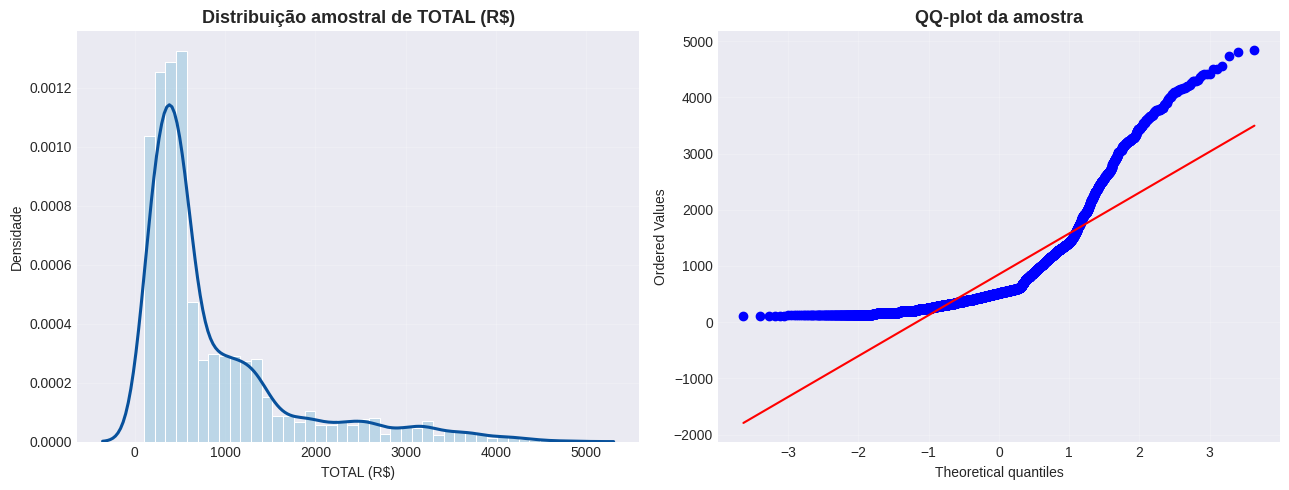

In [22]:
y_norm = resultado["normalidade"]["amostra"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(
    y_norm,
    bins=40,
    stat="density",
    color="#9ecae1",
    edgecolor="white",
    alpha=0.60,
    ax=axes[0],
)
sns.kdeplot(
    y_norm,
    color="#08519c",
    linewidth=2.2,
    ax=axes[0],
)

axes[0].set_title("Distribuição amostral de TOTAL (R$)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("TOTAL (R$)")
axes[0].set_ylabel("Densidade")
axes[0].grid(alpha=0.20)

stats.probplot(y_norm, dist="norm", plot=axes[1])
axes[1].set_title("QQ-plot da amostra", fontsize=13, fontweight="bold")
axes[1].grid(alpha=0.20)

plt.tight_layout()
sns.despine()
plt.show()


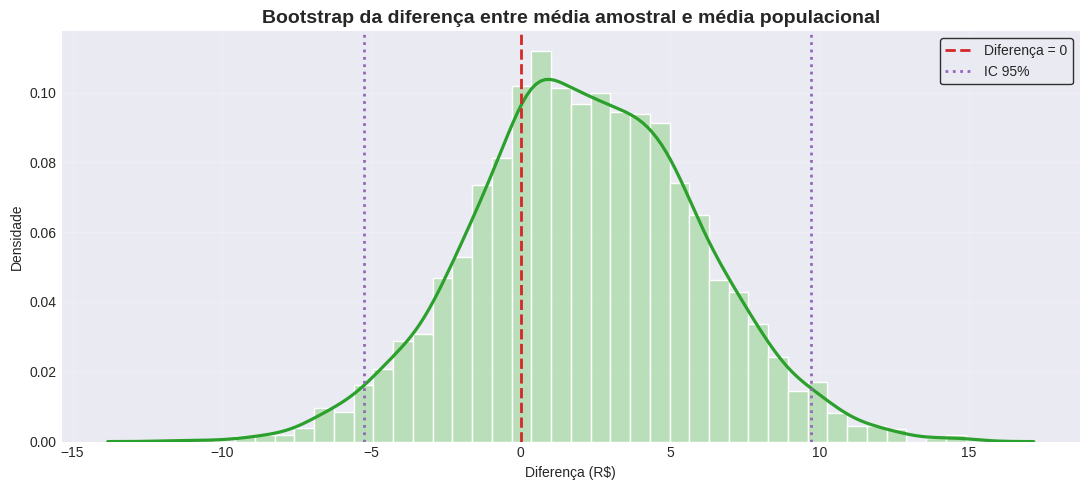

In [23]:
boot_diff = resultado["bootstrap"]["diffs"]
ci_inf, ci_sup = resultado["bootstrap"]["ic95_diff"]

plt.figure(figsize=(11, 5))

sns.histplot(
    boot_diff,
    bins=40,
    stat="density",
    color="#a1d99b",
    edgecolor="white",
    alpha=0.65,
)

sns.kdeplot(
    boot_diff,
    color="#2ca02c",
    linewidth=2.3,
)

plt.axvline(0, color="#d62728", linestyle="--", linewidth=2, label="Diferença = 0")
plt.axvline(ci_inf, color="#9467bd", linestyle=":", linewidth=2, label="IC 95%")
plt.axvline(ci_sup, color="#9467bd", linestyle=":", linewidth=2)

plt.title("Bootstrap da diferença entre média amostral e média populacional", fontsize=14, fontweight="bold")
plt.xlabel("Diferença (R$)")
plt.ylabel("Densidade")
plt.grid(alpha=0.20)
plt.legend(frameon=True, edgecolor="black")
plt.tight_layout()
sns.despine()
plt.show()


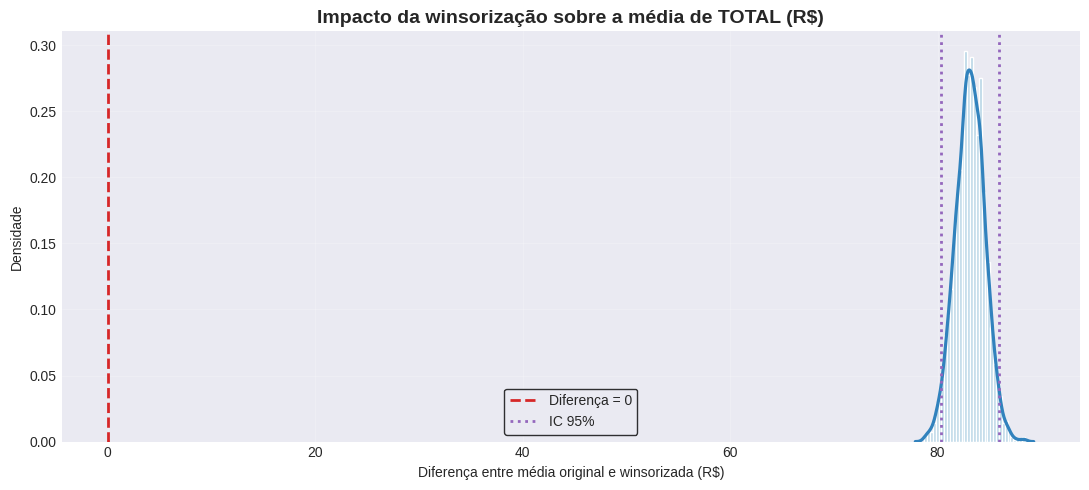

In [24]:
if resultado["impacto_outliers"] is not None:
    boot_dw = resultado["impacto_outliers"]["boot_diff"]
    ci_inf, ci_sup = resultado["impacto_outliers"]["ic95_diff"]

    plt.figure(figsize=(11, 5))

    sns.histplot(
        boot_dw,
        bins=35,
        stat="density",
        color="#9ecae1",
        edgecolor="white",
        alpha=0.65,
    )

    sns.kdeplot(
        boot_dw,
        color="#3182bd",
        linewidth=2.3,
    )

    plt.axvline(0, color="#d62728", linestyle="--", linewidth=2, label="Diferença = 0")
    plt.axvline(ci_inf, color="#9467bd", linestyle=":", linewidth=2, label="IC 95%")
    plt.axvline(ci_sup, color="#9467bd", linestyle=":", linewidth=2)

    plt.title("Impacto da winsorização sobre a média de TOTAL (R$)", fontsize=14, fontweight="bold")
    plt.xlabel("Diferença entre média original e winsorizada (R$)")
    plt.ylabel("Densidade")
    plt.grid(alpha=0.20)
    plt.legend(frameon=True, edgecolor="black")
    plt.tight_layout()
    sns.despine()
    plt.show()


Os resultados da Atividade A1.3 indicaram que a variável `TOTAL (R$)` não apresenta distribuição normal, conforme evidenciado pelo teste de Shapiro-Wilk (`p < 0,001`) e pelo QQ-plot. Ainda assim, considerando o grande tamanho amostral, a inferência sobre a média foi conduzida com base na robustez do Teorema Central do Limite e complementada por bootstrap.

Na comparação entre a população e a amostra ideal (`n = 51.400`), observou-se média populacional de `851,19` e média amostral de `853,36`. O teste de hipótese para a média apresentou `p = 0,5644`, não havendo evidências estatísticas para rejeitar `H0`. De forma consistente, a distribuição bootstrap da diferença entre as médias incluiu o valor zero no intervalo de confiança de 95%, reforçando a conclusão de que a amostra ideal pode ser considerada representativa da população.

Por fim, a análise do impacto da winsorização mostrou diferença relevante entre a média original e a média winsorizada da variável `TOTAL (R$)`, indicando que os valores extremos exercem influência importante sobre essa medida. Assim, os resultados sugerem que a amostra ideal é estatisticamente adequada para representar a população, ao mesmo tempo em que recomendam cautela na interpretação da média em presença de outliers.


#### A1.3.1: Teste de normalidade

Nesta etapa, avalia-se se as principais variáveis numéricas da base apresentam comportamento compatível com a distribuição normal. Para isso, utiliza-se o teste de Shapiro-Wilk em amostras controladas, complementado por histogramas e QQ-plots, permitindo combinar evidência estatística formal e diagnóstico visual.


In [25]:
# Funções Auxiliares

def teste_shapiro_amostra(serie, n_amostra=5000, alpha=0.05, random_state=42):
    serie = serie.dropna()

    if len(serie) == 0:
        return np.nan, np.nan, "Sem dados", serie

    n_use = min(n_amostra, len(serie))
    amostra = serie.sample(n=n_use, random_state=random_state) if len(serie) > n_use else serie

    w, p = shapiro(amostra)
    decisao = "Rejeita normalidade" if p < alpha else "Não rejeita normalidade"

    return float(w), float(p), decisao, amostra


def plot_normalidade(amostra, variavel):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sns.histplot(
        amostra,
        bins=40,
        stat="density",
        color="#9ecae1",
        edgecolor="white",
        alpha=0.60,
        ax=axes[0],
    )
    sns.kdeplot(
        amostra,
        color="#08519c",
        linewidth=2.2,
        ax=axes[0],
    )

    axes[0].set_title(f"Distribuição amostral de {variavel}", fontsize=13, fontweight="bold")
    axes[0].set_xlabel(variavel)
    axes[0].set_ylabel("Densidade")
    axes[0].grid(alpha=0.20)

    stats.probplot(amostra, dist="norm", plot=axes[1])
    axes[1].set_title(f"QQ-plot de {variavel}", fontsize=13, fontweight="bold")
    axes[1].grid(alpha=0.20)

    plt.tight_layout()
    sns.despine()
    plt.show()


In [27]:
# Função principal

def AtividadeA1_3_1(n_amostra=5000, alpha=0.05, random_state=42):
    variaveis = ["RENDA BRUTO (R$)", "NOTA DE SATISFAÇÃO (%)", "TOTAL (R$)"]
    resultados = []

    for var in variaveis:
        serie = table[var].dropna()

        media = float(serie.mean())
        dp = float(serie.std(ddof=1))
        skew = float(serie.skew())
        kurt = float(serie.kurtosis())
        n_unicos = int(serie.nunique())

        frequencias = serie.value_counts()
        moda = frequencias.index[0]
        perc_moda = float((frequencias.iloc[0] / len(serie)) * 100)

        w, p, decisao, amostra = teste_shapiro_amostra(
            serie,
            n_amostra=n_amostra,
            alpha=alpha,
            random_state=random_state,
        )

        observacao = ""
        if perc_moda >= 50:
            observacao = "Alta concentração em um único valor"

        resultados.append(
            {
                "Variável": var,
                "N": int(len(serie)),
                "n amostra": int(len(amostra)),
                "W": w,
                "p-valor": p,
                "Decisão": decisao,
                "Média": media,
                "DP": dp,
                "Assimetria": skew,
                "Curtose": kurt,
                "Valores únicos": n_unicos,
                "Moda": moda,
                "% moda": perc_moda,
                "Observação": observacao,
                "Amostra": amostra,
            }
        )

    df_resultados = pd.DataFrame(resultados)

    RESULTADOS["A1.3.1"] = {
        "tabela": df_resultados.drop(columns=["Amostra"]),
        "amostras": {row["Variável"]: row["Amostra"] for _, row in df_resultados.iterrows()},
        "parametros": {
            "n_amostra": int(n_amostra),
            "alpha": float(alpha),
            "random_state": int(random_state),
        },
    }

    print("Teste de normalidade concluído.")
    print(f"Variáveis analisadas: {len(variaveis)}")


In [28]:
# Execução + tabela formatada

AtividadeA1_3_1()

resultado = RESULTADOS["A1.3.1"]

tabela_normalidade = resultado["tabela"].copy()
tabela_normalidade[["W", "p-valor", "Média", "DP", "Assimetria", "Curtose", "% moda"]] = (
    tabela_normalidade[["W", "p-valor", "Média", "DP", "Assimetria", "Curtose", "% moda"]].round(4)
)

display(tabela_normalidade)


Teste de normalidade concluído.
Variáveis analisadas: 3


,Variável,N,n amostra,W,p-valor,Decisão,Média,DP,Assimetria,Curtose,Valores únicos,Moda,% moda,Observação
0,RENDA BRUTO (R$),1120000,5000,0.7198,0.0,Rejeita normalidade,7722.3349,6639.5538,1.4110,0.6259,398958,3265.87,0.0048,
1,NOTA DE SATISFAÇÃO (%),1120000,5000,0.2177,0.0,Rejeita normalidade,68.9695,1.3566,5.9103,40.2667,202,68.68,93.1174,Alta concentração em um único valor
2,TOTAL (R$),1120000,5000,0.7503,0.0,Rejeita normalidade,851.1867,852.0839,1.9738,3.5316,253143,132.41,0.0057,


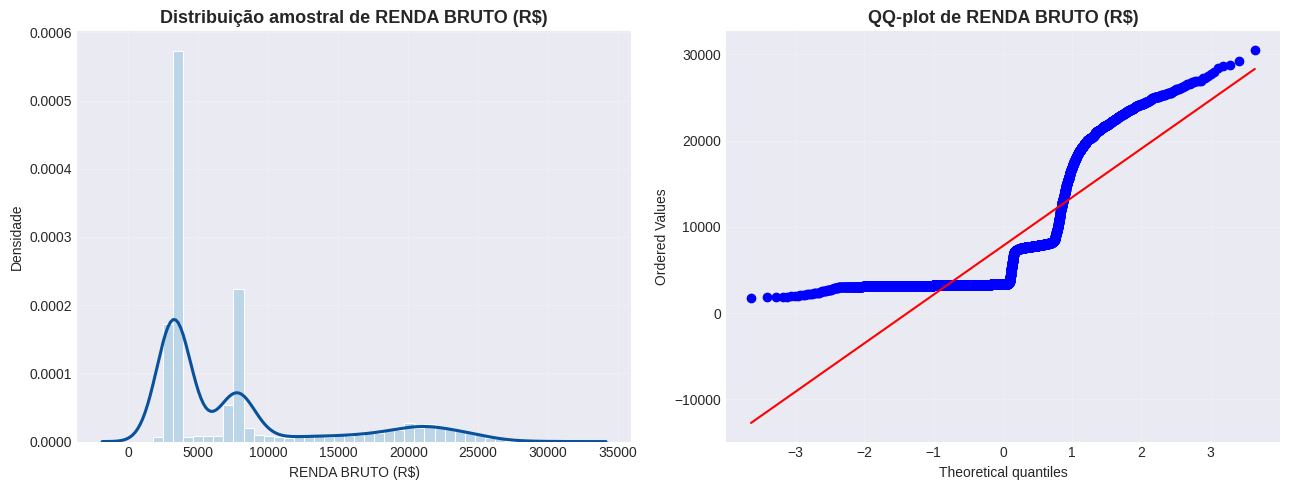

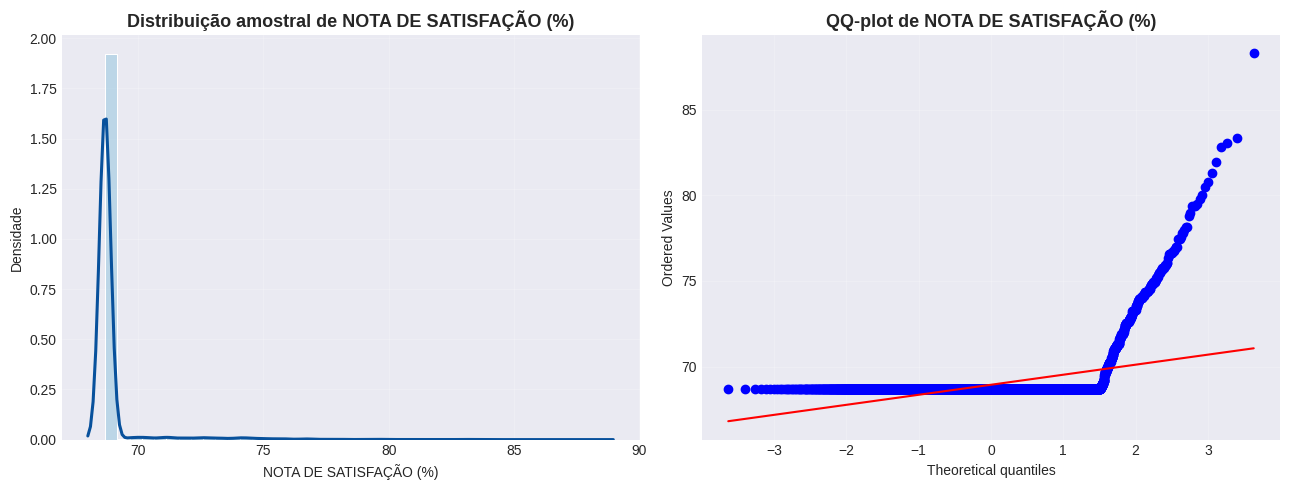

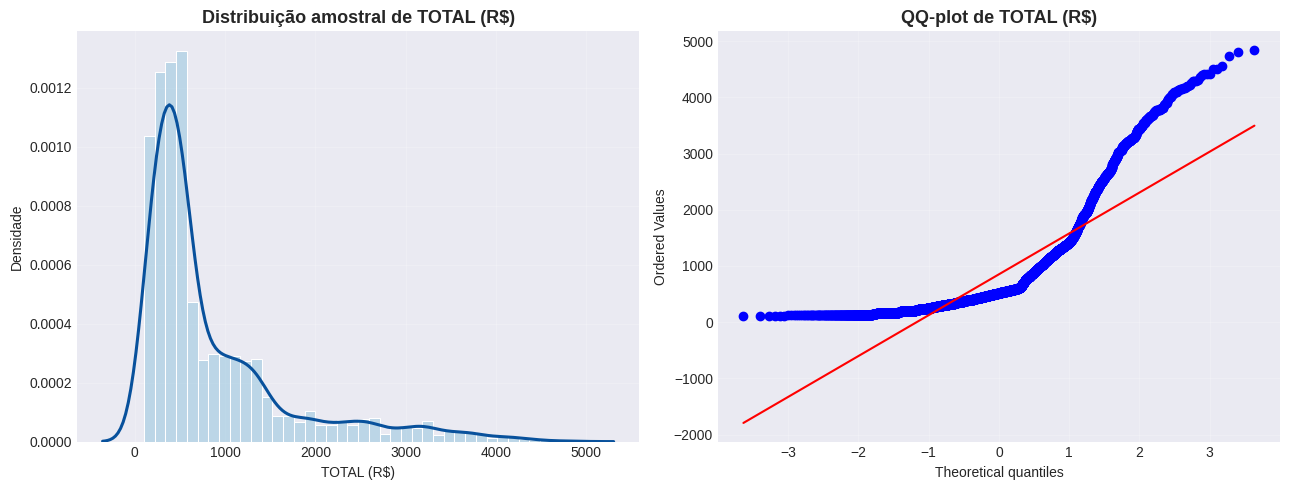

In [29]:
for variavel, amostra in resultado["amostras"].items():
    plot_normalidade(amostra, variavel)


Os resultados do teste de Shapiro-Wilk indicaram rejeição da hipótese de normalidade para as três variáveis analisadas, uma vez que todos os p-valores foram inferiores a `0,05`. Esse resultado também foi confirmado visualmente pelos histogramas e QQ-plots, que evidenciaram assimetria, concentração de valores e desvios importantes em relação ao comportamento esperado sob distribuição normal.

A variável `NOTA DE SATISFAÇÃO (%)` apresentou o caso mais acentuado de não normalidade, com forte concentração no valor `68,68`, correspondente a `93,12%` dos registros, além de elevada assimetria (`5,91`) e curtose (`40,27`). Já as variáveis `RENDA BRUTO (R$)` e `TOTAL (R$)` também apresentaram assimetria positiva (`1,41` e `1,97`, respectivamente), indicando distribuições com cauda à direita e presença de valores extremos.

Dessa forma, conclui-se que as variáveis numéricas analisadas não seguem distribuição normal. Ainda assim, considerando o grande volume amostral e o foco inferencial sobre médias, a continuidade das análises permanece metodologicamente adequada com apoio do Teorema Central do Limite e da validação complementar por bootstrap nas etapas subsequentes.


#### A1.3.2: Teste de independência

Nesta etapa, avalia-se se existe associação estatisticamente significativa entre as variáveis categóricas `REGIÃO` e `TIPO DA CONTA`. Para isso, utiliza-se o teste Qui-Quadrado de independência, complementado pela análise do tamanho de efeito, das frequências esperadas e dos resíduos padronizados.


In [30]:
# Funções auxiliares

def interpretar_cramers_v(v):
    if np.isnan(v):
        return "N/A"
    if v < 0.05:
        return "Efeito desprezível"
    if v < 0.10:
        return "Efeito fraco"
    if v < 0.30:
        return "Efeito moderado"
    return "Efeito forte"


def preparar_tabela_contingencia(dados, var1, var2):
    df = dados[[var1, var2]].dropna().copy()
    df[var1] = df[var1].astype(str).str.strip()
    df[var2] = df[var2].astype(str).str.strip()
    df = df[(df[var1] != "") & (df[var2] != "")]

    contingencia = pd.crosstab(df[var1], df[var2])
    return df, contingencia


In [31]:
# Função principal

def AtividadeA1_3_2():
    alpha = 0.05
    var1 = "REGIÃO"
    var2 = "TIPO DA CONTA"

    df, cont = preparar_tabela_contingencia(table, var1, var2)
    n_validos = len(df)

    chi2, p_val, dof, expected = chi2_contingency(cont.values, correction=False)
    decisao = "Rejeita H0" if p_val < alpha else "Não rejeita H0"

    r, c = cont.shape
    k = min(r - 1, c - 1)
    cramers_v = np.sqrt((chi2 / n_validos) / k) if (k > 0 and n_validos > 0) else np.nan
    interpretacao_v = interpretar_cramers_v(cramers_v)

    expected_df = pd.DataFrame(expected, index=cont.index, columns=cont.columns)
    qtd_expected_lt5 = int((expected_df < 5).sum().sum())
    total_celulas = int(expected_df.size)
    perc_expected_lt5 = (qtd_expected_lt5 / total_celulas) * 100 if total_celulas > 0 else np.nan

    residuos = (cont - expected_df) / np.sqrt(expected_df)
    residuos = residuos.replace([np.inf, -np.inf], np.nan)

    top_residuos = (
        residuos.abs()
        .stack()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )
    top_residuos.columns = [var1, var2, "|Resíduo padronizado|"]

    RESULTADOS["A1.3.2"] = {
        "variaveis": (var1, var2),
        "n_validos": int(n_validos),
        "alpha": float(alpha),
        "chi2": float(chi2),
        "p_value": float(p_val),
        "dof": int(dof),
        "decisao": decisao,
        "cramers_v": float(cramers_v) if not np.isnan(cramers_v) else None,
        "interpretacao_cramers_v": interpretacao_v,
        "qtd_expected_lt5": int(qtd_expected_lt5),
        "perc_expected_lt5": float(perc_expected_lt5) if np.isfinite(perc_expected_lt5) else None,
        "contingencia": cont,
        "esperadas": expected_df,
        "residuos_padronizados": residuos,
        "top_residuos": top_residuos,
    }

    print("Teste de independência concluído.")
    print(f"Variáveis analisadas: {var1} e {var2}")


In [32]:
# Execução + tabelas

AtividadeA1_3_2()

resultado = RESULTADOS["A1.3.2"]

Teste de independência concluído.
Variáveis analisadas: REGIÃO e TIPO DA CONTA


In [33]:
resumo_independencia = pd.DataFrame(
    [
        {
            "Variáveis": f"{resultado['variaveis'][0]} x {resultado['variaveis'][1]}",
            "N válidos": resultado["n_validos"],
            "Qui-quadrado": resultado["chi2"],
            "gl": resultado["dof"],
            "p-valor": resultado["p_value"],
            "Decisão": resultado["decisao"],
            "Cramér's V": resultado["cramers_v"],
            "Interpretação": resultado["interpretacao_cramers_v"],
            "% esperado < 5": resultado["perc_expected_lt5"],
        }
    ]
)

resumo_independencia[["Qui-quadrado", "p-valor", "Cramér's V", "% esperado < 5"]] = (
    resumo_independencia[["Qui-quadrado", "p-valor", "Cramér's V", "% esperado < 5"]].round(4)
)

display(resumo_independencia)
display(resultado["contingencia"])
display(resultado["top_residuos"])


,Variáveis,N válidos,Qui-quadrado,gl,p-valor,Decisão,Cramér's V,Interpretação,% esperado < 5
0,REGIÃO x TIPO DA CONTA,1120000,7.2988,8,0.5048,Não rejeita H0,0.0018,Efeito desprezível,0.0


TIPO DA CONTA,ESSENTIAL,PRIME,VIP
REGIÃO,,,
CENTRO-OESTE,58287,18004,24263
NORDESTE,38854,11840,16107
NORTE,13183,3874,5427
SUDESTE,435957,133807,181229
SUL,103915,32049,43204


,REGIÃO,TIPO DA CONTA,|Resíduo padronizado|
0,NORTE,PRIME,2.092502
1,NORTE,ESSENTIAL,1.140632
2,SUL,PRIME,0.687614
3,CENTRO-OESTE,PRIME,0.643782
4,NORDESTE,PRIME,0.580571
5,NORDESTE,ESSENTIAL,0.375126
6,CENTRO-OESTE,ESSENTIAL,0.363518
7,SUL,ESSENTIAL,0.303193
8,SUL,VIP,0.120621
9,NORDESTE,VIP,0.082947


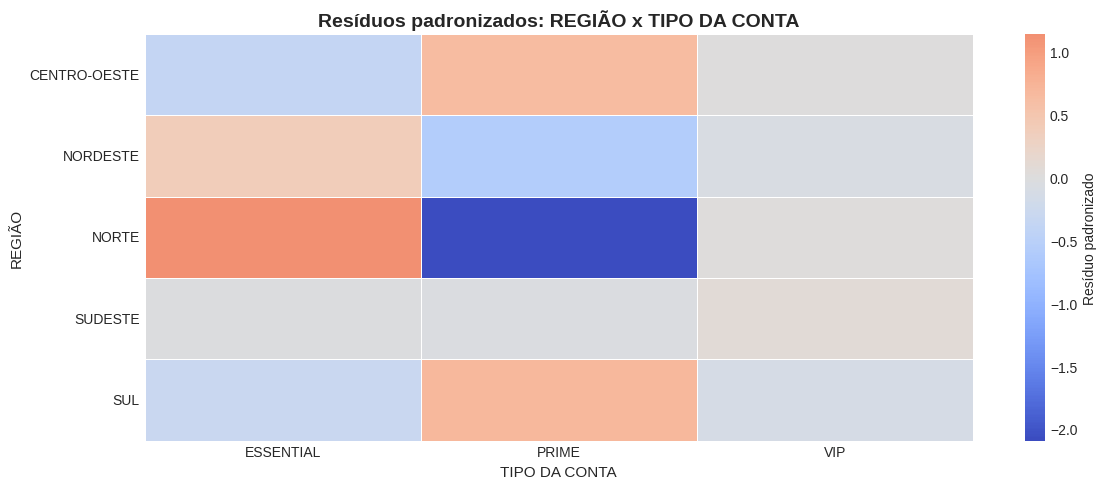

In [34]:
plt.figure(figsize=(12, 5))

sns.heatmap(
    resultado["residuos_padronizados"],
    cmap="coolwarm",
    center=0,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"label": "Resíduo padronizado"},
)

plt.title(
    f"Resíduos padronizados: {resultado['variaveis'][0]} x {resultado['variaveis'][1]}",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel(resultado["variaveis"][1], fontsize=11)
plt.ylabel(resultado["variaveis"][0], fontsize=11)

plt.tight_layout()
sns.despine(left=True, bottom=True)
plt.show()


O teste Qui-Quadrado não indicou evidência estatisticamente significativa de associação entre `REGIÃO` e `TIPO DA CONTA`, uma vez que o p-valor obtido foi `0,5048`, superior ao nível de significância de `5%`. Assim, não se rejeita a hipótese nula de independência entre as variáveis analisadas.

Além disso, o valor de `Cramér's V = 0,0018` foi classificado como efeito desprezível, indicando que a relação entre as categorias é praticamente inexistente do ponto de vista prático. Os resíduos padronizados também apresentaram magnitudes baixas, sem desvios expressivos que sugerissem combinações regionais fortemente acima ou abaixo do esperado sob independência.

Dessa forma, conclui-se que, na base analisada, `REGIÃO` e `TIPO DA CONTA` podem ser tratadas como estatisticamente independentes, não havendo evidências de associação relevante entre essas variáveis.


#### A1.3.3: Teste de distribuição

Nesta etapa, avalia-se se a variável `RENDA BRUTO (R$)` apresenta variâncias homogêneas entre os grupos da variável `REGIÃO`. Para isso, utiliza-se o teste de Levene com centro na mediana, complementado por medidas descritivas e visualizações da distribuição por grupo.


In [35]:
# Funções auxiliares

def calcular_iqr(serie):
    return float(serie.quantile(0.75) - serie.quantile(0.25))


def preparar_dados_levene(dados, coluna_valor, coluna_grupo):
    df = dados[[coluna_valor, coluna_grupo]].copy()

    df = df.dropna(subset=[coluna_valor, coluna_grupo])
    df[coluna_grupo] = df[coluna_grupo].astype(str).str.strip()
    df = df[df[coluna_grupo] != ""]

    df[coluna_valor] = pd.to_numeric(df[coluna_valor], errors="coerce")
    df = df.dropna(subset=[coluna_valor])
    df = df[df[coluna_valor] >= 0]

    return df


In [36]:
# Função principal

def AtividadeA1_3_3():
    alpha = 0.05
    coluna_valor = "RENDA BRUTO (R$)"
    coluna_grupo = "REGIÃO"
    ordem_preferida = ["NORTE", "NORDESTE", "CENTRO-OESTE", "SUDESTE", "SUL"]

    df = preparar_dados_levene(table, coluna_valor, coluna_grupo)

    n_validos = len(df)
    grupos = df[coluna_grupo].value_counts().sort_values(ascending=False)
    qtd_grupos = len(grupos)

    ordem = [g for g in ordem_preferida if g in grupos.index.tolist()]
    ordem += [g for g in grupos.index.tolist() if g not in ordem]

    resumo = (
        df.groupby(coluna_grupo, as_index=False)[coluna_valor]
        .agg(
            n="count",
            media="mean",
            dp="std",
            mediana="median",
            q1=lambda s: float(s.quantile(0.25)),
            q3=lambda s: float(s.quantile(0.75)),
            iqr=calcular_iqr,
            minimo="min",
            maximo="max",
        )
    )

    resumo[coluna_grupo] = pd.Categorical(resumo[coluna_grupo], categories=ordem, ordered=True)
    resumo = resumo.sort_values(coluna_grupo).reset_index(drop=True)

    series_por_grupo = [
        df.loc[df[coluna_grupo] == g, coluna_valor].values
        for g in ordem
    ]

    estatistica, p_valor = levene(*series_por_grupo, center="median")
    decisao = "Rejeita H0" if p_valor < alpha else "Não rejeita H0"

    RESULTADOS["A1.3.3"] = {
        "coluna_valor": coluna_valor,
        "coluna_grupo": coluna_grupo,
        "n_validos": int(n_validos),
        "qtd_grupos": int(qtd_grupos),
        "ordem_grupos": ordem,
        "n_por_grupo": grupos.to_dict(),
        "estatistica_levene": float(estatistica),
        "p_valor_levene": float(p_valor),
        "alpha": float(alpha),
        "decisao": decisao,
        "resumo_por_grupo": resumo,
        "dados_limpos": df,
    }

    print("Teste de distribuição concluído.")
    print(f"Variável numérica: {coluna_valor}")
    print(f"Variável de agrupamento: {coluna_grupo}")


In [37]:
# Execução + tabelas

AtividadeA1_3_3()

resultado = RESULTADOS["A1.3.3"]


Teste de distribuição concluído.
Variável numérica: RENDA BRUTO (R$)
Variável de agrupamento: REGIÃO


In [38]:
resumo_levene = pd.DataFrame(
    [
        {
            "Variável": resultado["coluna_valor"],
            "Grupo": resultado["coluna_grupo"],
            "N válidos": resultado["n_validos"],
            "Qtd. grupos": resultado["qtd_grupos"],
            "Estatística de Levene": resultado["estatistica_levene"],
            "p-valor": resultado["p_valor_levene"],
            "Decisão": resultado["decisao"],
        }
    ]
)

resumo_levene[["Estatística de Levene", "p-valor"]] = (
    resumo_levene[["Estatística de Levene", "p-valor"]].round(4)
)

display(resumo_levene)
display(pd.Series(resultado["n_por_grupo"], name="n").to_frame())
display(resultado["resumo_por_grupo"].round(2))


,Variável,Grupo,N válidos,Qtd. grupos,Estatística de Levene,p-valor,Decisão
0,RENDA BRUTO (R$),REGIÃO,1120000,5,1.6315,0.1632,Não rejeita H0


,n
SUDESTE,750993
SUL,179168
CENTRO-OESTE,100554
NORDESTE,66801
NORTE,22484


,REGIÃO,n,media,dp,mediana,q1,q3,iqr,minimo,maximo
0,NORTE,22484,7628.80,6587.61,3358.63,3239.82,8030.18,4790.36,1780.56,29295.96
1,NORDESTE,66801,7701.13,6627.12,3364.16,3240.76,8054.54,4813.78,1766.01,31122.07
2,CENTRO-OESTE,100554,7737.66,6659.96,3366.24,3240.99,8073.78,4832.79,1760.19,30989.75
3,SUDESTE,750993,7721.42,6636.43,3364.99,3240.65,8069.76,4829.11,1756.31,33508.25
4,SUL,179168,7737.22,6652.22,3366.80,3240.68,8076.13,4835.45,1757.28,32878.75


In [39]:
df_plot = resultado["dados_limpos"].copy()
coluna_valor = resultado["coluna_valor"]
coluna_grupo = resultado["coluna_grupo"]
ordem = resultado["ordem_grupos"]

y_cap = df_plot[coluna_valor].quantile(0.99)
df_plot["_valor_plot"] = df_plot[coluna_valor].clip(upper=y_cap)


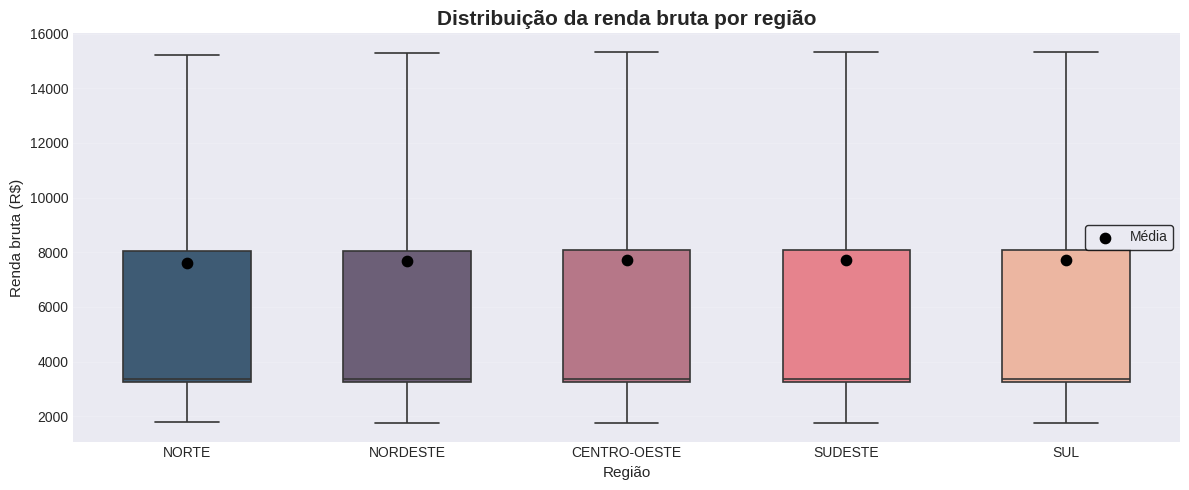

In [42]:
cores_regiao = ["#355C7D", "#6C5B7B", "#C06C84", "#F67280", "#F8B195"]

plt.figure(figsize=(12, 5))

sns.boxplot(
    data=df_plot,
    x=coluna_grupo,
    y="_valor_plot",
    order=ordem,
    showfliers=False,
    width=0.58,
    palette=cores_regiao,
    linewidth=1.2,
)

medias = (
    df_plot.groupby(coluna_grupo)["_valor_plot"]
    .mean()
    .reindex(ordem)
)

plt.scatter(
    range(len(ordem)),
    medias.values,
    color="black",
    s=55,
    zorder=5,
    label="Média"
)

plt.title("Distribuição da renda bruta por região", fontsize=15, fontweight="bold")
plt.xlabel("Região", fontsize=11)
plt.ylabel("Renda bruta (R$)", fontsize=11)
plt.grid(axis="y", alpha=0.18)
plt.legend(frameon=True, edgecolor="black")
plt.tight_layout()
sns.despine()
plt.show()



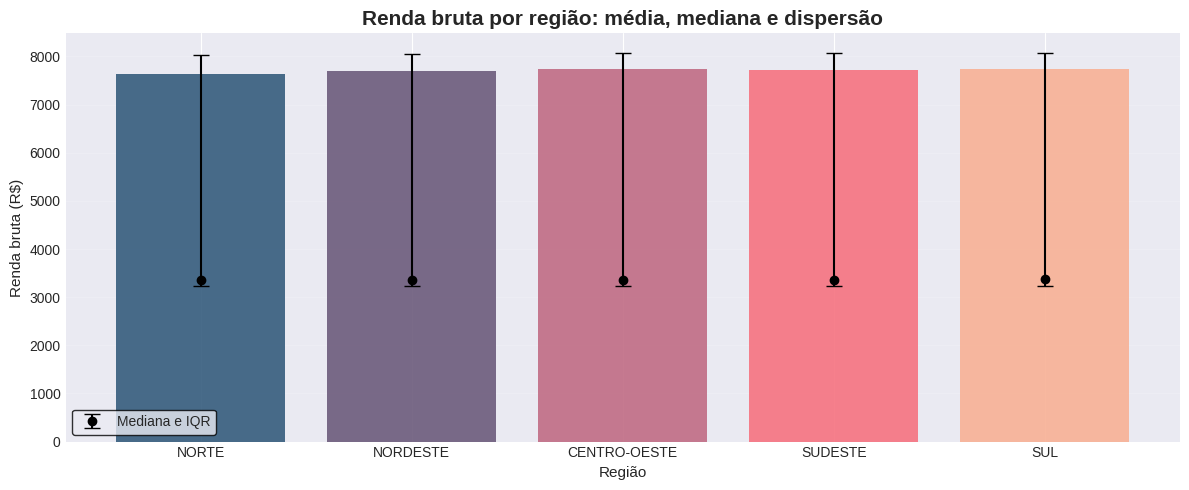

In [43]:
resumo_plot = resultado["resumo_por_grupo"].copy()

plt.figure(figsize=(12, 5))

bars = plt.bar(
    resumo_plot["REGIÃO"],
    resumo_plot["media"],
    color=["#355C7D", "#6C5B7B", "#C06C84", "#F67280", "#F8B195"],
    alpha=0.90
)

plt.errorbar(
    resumo_plot["REGIÃO"],
    resumo_plot["mediana"],
    yerr=[resumo_plot["mediana"] - resumo_plot["q1"], resumo_plot["q3"] - resumo_plot["mediana"]],
    fmt="o",
    color="black",
    capsize=6,
    linewidth=1.5,
    label="Mediana e IQR"
)

plt.title("Renda bruta por região: média, mediana e dispersão", fontsize=15, fontweight="bold")
plt.xlabel("Região", fontsize=11)
plt.ylabel("Renda bruta (R$)", fontsize=11)
plt.grid(axis="y", alpha=0.18)
plt.legend(frameon=True, edgecolor="black")
plt.tight_layout()
sns.despine()
plt.show()


O teste de Levene não indicou evidência estatisticamente significativa para rejeitar a hipótese nula de homogeneidade de variâncias entre os grupos de `REGIÃO`, uma vez que o p-valor obtido foi `0,1632`, superior ao nível de significância de `5%`. Assim, a dispersão da variável `RENDA BRUTO (R$)` pode ser considerada estatisticamente semelhante entre as regiões analisadas.

As estatísticas descritivas por grupo reforçam essa interpretação, pois as médias, medianas e intervalos interquartis apresentaram valores bastante próximos entre si. Embora existam pequenas diferenças numéricas entre as regiões, não se observou evidência de heterocedasticidade relevante do ponto de vista estatístico.

Dessa forma, conclui-se que a suposição de homogeneidade de variâncias é adequada para a variável `RENDA BRUTO (R$)` quando comparada entre os grupos de `REGIÃO`, o que favorece a aplicação de métodos comparativos entre médias que dependem desse pressuposto nas etapas subsequentes.


#### A1.3.4: Teste das médias amostrais

Nesta etapa, compara-se a média da variável `NOTA DE SATISFAÇÃO (%)` entre os grupos de `TIPO DA CONTA`. Para isso, são analisadas as estatísticas descritivas por grupo, a homogeneidade de variâncias e, em seguida, aplicado o teste comparativo mais adequado entre ANOVA clássica, ANOVA de Welch ou alternativa robusta.


In [44]:
# Funções auxiliares

def preparar_dados_medias(dados, coluna_valor, coluna_grupo):
    df = dados[[coluna_valor, coluna_grupo]].copy()

    df = df.dropna(subset=[coluna_valor, coluna_grupo])
    df[coluna_grupo] = df[coluna_grupo].astype(str).str.strip()
    df = df[df[coluna_grupo] != ""]

    df[coluna_valor] = pd.to_numeric(df[coluna_valor], errors="coerce")
    df = df.dropna(subset=[coluna_valor])

    return df


def corrigir_holm(p_values):
    p_values = np.asarray(p_values, dtype=float)
    m = len(p_values)
    ordem = np.argsort(p_values)
    ajustados = np.empty(m, dtype=float)

    anterior = 0.0
    for rank, idx in enumerate(ordem):
        valor = min(1.0, (m - rank) * p_values[idx])
        valor = max(valor, anterior)
        ajustados[idx] = valor
        anterior = valor

    return ajustados


In [45]:
# Função principal

def AtividadeA1_3_4():
    alpha = 0.05
    coluna_valor = "NOTA DE SATISFAÇÃO (%)"
    coluna_grupo = "TIPO DA CONTA"

    df = preparar_dados_medias(table, coluna_valor, coluna_grupo)

    n_validos = len(df)
    n_por_grupo = df[coluna_grupo].value_counts()
    grupos_ordem = n_por_grupo.index.tolist()

    resumo = (
        df.groupby(coluna_grupo)[coluna_valor]
        .agg(
            n="count",
            media="mean",
            dp="std",
            mediana="median",
            q1=lambda s: float(s.quantile(0.25)),
            q3=lambda s: float(s.quantile(0.75)),
            minimo="min",
            maximo="max",
        )
        .reset_index()
    )
    resumo["iqr"] = resumo["q3"] - resumo["q1"]
    resumo = resumo.merge(
        n_por_grupo.rename("n_ref"),
        left_on=coluna_grupo,
        right_index=True,
        how="left",
    )
    resumo = resumo.sort_values("n_ref", ascending=False).drop(columns=["n_ref"])

    arrays = [df.loc[df[coluna_grupo] == g, coluna_valor].values for g in grupos_ordem]

    lev_stat, lev_p = levene(*arrays, center="median")
    lev_resultado = "Rejeita H0" if lev_p < alpha else "Não rejeita H0"

    metodo = "ANOVA clássica" if lev_p >= alpha else "ANOVA de Welch"
    estatistica_principal = None
    p_valor_principal = None
    info_teste = {}

    if metodo == "ANOVA clássica":
        f_stat, p_val = f_oneway(*arrays)
        estatistica_principal = float(f_stat)
        p_valor_principal = float(p_val)
        info_teste = {"F": float(f_stat)}
    else:
        try:
            from statsmodels.stats.oneway import anova_oneway

            res = anova_oneway(df[coluna_valor], df[coluna_grupo], use_var="unequal")
            estatistica_principal = float(res.statistic)
            p_valor_principal = float(res.pvalue)
            info_teste = {
                "F_welch": float(res.statistic),
                "gl_num": float(res.df_num),
                "gl_den": float(res.df_denom),
            }
        except Exception:
            from scipy.stats import kruskal

            metodo = "Kruskal-Wallis"
            h_stat, p_val = kruskal(*arrays)
            estatistica_principal = float(h_stat)
            p_valor_principal = float(p_val)
            info_teste = {"H": float(h_stat)}

    decisao_principal = "Rejeita H0" if p_valor_principal < alpha else "Não rejeita H0"

    pares = []
    p_brutos = []

    for i in range(len(grupos_ordem)):
        for j in range(i + 1, len(grupos_ordem)):
            g1, g2 = grupos_ordem[i], grupos_ordem[j]
            x1 = df.loc[df[coluna_grupo] == g1, coluna_valor].values
            x2 = df.loc[df[coluna_grupo] == g2, coluna_valor].values

            t_stat, p_val = ttest_ind(x1, x2, equal_var=False)
            pares.append((g1, g2, float(t_stat), float(p_val)))
            p_brutos.append(float(p_val))

    posthoc = pd.DataFrame(pares, columns=["grupo_1", "grupo_2", "t_welch", "p_value"])
    posthoc["p_holm"] = corrigir_holm(posthoc["p_value"].values)
    posthoc["diferença_significativa"] = posthoc["p_holm"] < alpha

    eta2_aprox = None
    k = len(grupos_ordem)
    try:
        f_ref = info_teste.get("F", info_teste.get("F_welch"))
        if f_ref is not None:
            eta2_aprox = (f_ref * (k - 1)) / (f_ref * (k - 1) + (n_validos - k))
    except Exception:
        eta2_aprox = None

    RESULTADOS["A1.3.4"] = {
        "coluna_valor": coluna_valor,
        "coluna_grupo": coluna_grupo,
        "n_validos": int(n_validos),
        "n_por_grupo": n_por_grupo.to_dict(),
        "resumo_por_grupo": resumo,
        "levene_stat": float(lev_stat),
        "levene_p_value": float(lev_p),
        "levene_resultado": lev_resultado,
        "metodo": metodo,
        "info_teste": info_teste,
        "estatistica_principal": estatistica_principal,
        "p_value_principal": p_valor_principal,
        "decisao_principal": decisao_principal,
        "eta2_aprox": float(eta2_aprox) if eta2_aprox is not None else None,
        "posthoc_welch_holm": posthoc,
        "dados_limpos": df,
    }

    print("Teste das médias concluído.")
    print(f"Variável analisada: {coluna_valor}")
    print(f"Grupos analisados: {len(grupos_ordem)}")


In [46]:
# Execução + tabelas

AtividadeA1_3_4()

resultado = RESULTADOS["A1.3.4"]


Teste das médias concluído.
Variável analisada: NOTA DE SATISFAÇÃO (%)
Grupos analisados: 3


In [47]:
resumo_teste_medias = pd.DataFrame(
    [
        {
            "Variável": resultado["coluna_valor"],
            "Grupo": resultado["coluna_grupo"],
            "N válidos": resultado["n_validos"],
            "Método": resultado["metodo"],
            "Levene p-valor": resultado["levene_p_value"],
            "Teste p-valor": resultado["p_value_principal"],
            "Decisão": resultado["decisao_principal"],
            "Eta² aprox.": resultado["eta2_aprox"],
        }
    ]
)

resumo_teste_medias[["Levene p-valor", "Teste p-valor", "Eta² aprox."]] = (
    resumo_teste_medias[["Levene p-valor", "Teste p-valor", "Eta² aprox."]].round(4)
)

display(resumo_teste_medias)
display(resultado["resumo_por_grupo"].round(3))
display(resultado["posthoc_welch_holm"].sort_values("p_holm").round(4))


,Variável,Grupo,N válidos,Método,Levene p-valor,Teste p-valor,Decisão,Eta² aprox.
0,NOTA DE SATISFAÇÃO (%),TIPO DA CONTA,1120000,ANOVA de Welch,0.0,0.0,Rejeita H0,0.0545


,TIPO DA CONTA,n,media,dp,mediana,q1,q3,minimo,maximo,iqr
0,ESSENTIAL,650196,68.680,0.000,68.68,68.68,68.680,68.68,68.680,0.000
2,VIP,270230,68.681,0.048,68.68,68.68,68.680,68.68,78.578,0.000
1,PRIME,199574,70.304,2.856,68.68,68.68,71.104,68.68,92.112,2.424


,grupo_1,grupo_2,t_welch,p_value,p_holm,diferença_significativa
1,ESSENTIAL,PRIME,-253.9392,0.0,0.0,True
2,VIP,PRIME,-253.8134,0.0,0.0,True
0,ESSENTIAL,VIP,-6.9271,0.0,0.0,True


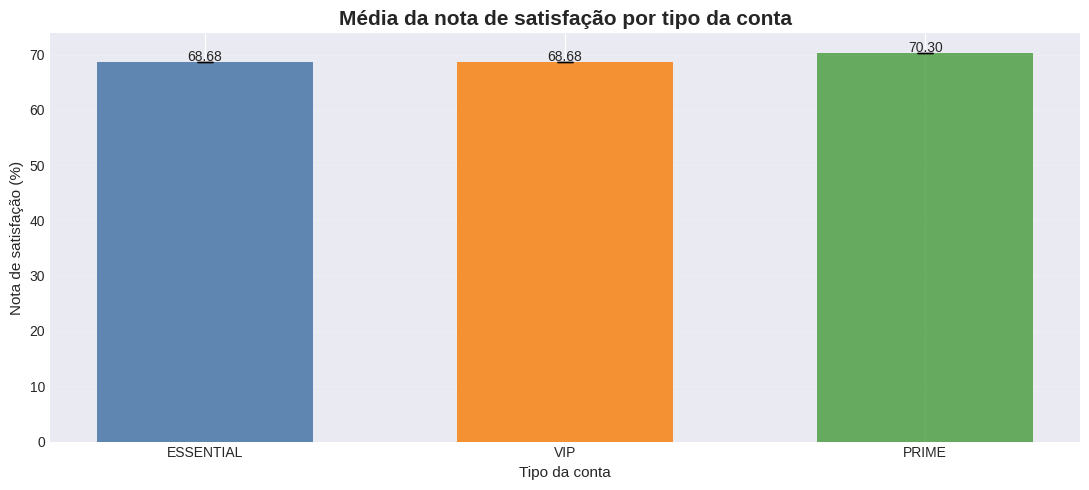

In [50]:
resumo_plot = resultado["resumo_por_grupo"].copy()
resumo_plot["se"] = resumo_plot["dp"] / np.sqrt(resumo_plot["n"])
resumo_plot["ic_inf"] = resumo_plot["media"] - 1.96 * resumo_plot["se"]
resumo_plot["ic_sup"] = resumo_plot["media"] + 1.96 * resumo_plot["se"]

plt.figure(figsize=(11, 5))

cores = ["#4C78A8", "#F58518", "#54A24B"]

plt.bar(
    resumo_plot["TIPO DA CONTA"],
    resumo_plot["media"],
    color=cores,
    alpha=0.88,
    width=0.6,
)

plt.errorbar(
    resumo_plot["TIPO DA CONTA"],
    resumo_plot["media"],
    yerr=1.96 * resumo_plot["se"],
    fmt="none",
    ecolor="black",
    elinewidth=1.6,
    capsize=6,
)

for i, valor in enumerate(resumo_plot["media"]):
    plt.text(i, valor + 0.15, f"{valor:.2f}", ha="center", fontsize=10)

plt.title("Média da nota de satisfação por tipo da conta", fontsize=15, fontweight="bold")
plt.xlabel("Tipo da conta", fontsize=11)
plt.ylabel("Nota de satisfação (%)", fontsize=11)
plt.grid(axis="y", alpha=0.18)
plt.tight_layout()
sns.despine()
plt.show()



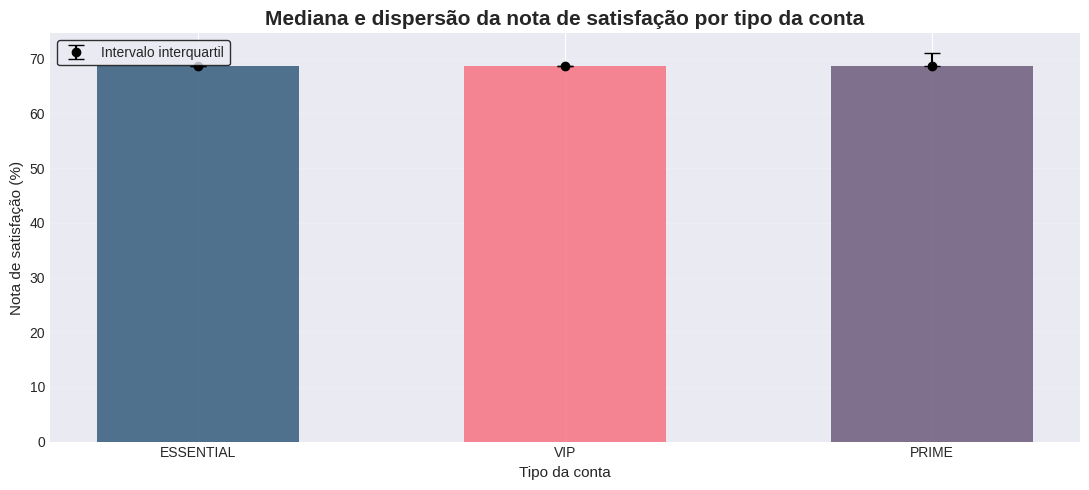

In [51]:
plt.figure(figsize=(11, 5))

x = np.arange(len(resumo_plot))

plt.bar(
    x,
    resumo_plot["mediana"],
    color=["#355C7D", "#F67280", "#6C5B7B"],
    alpha=0.85,
    width=0.55,
)

plt.errorbar(
    x,
    resumo_plot["mediana"],
    yerr=[resumo_plot["mediana"] - resumo_plot["q1"], resumo_plot["q3"] - resumo_plot["mediana"]],
    fmt="o",
    color="black",
    capsize=6,
    linewidth=1.5,
    label="Intervalo interquartil",
)

plt.xticks(x, resumo_plot["TIPO DA CONTA"])
plt.title("Mediana e dispersão da nota de satisfação por tipo da conta", fontsize=15, fontweight="bold")
plt.xlabel("Tipo da conta", fontsize=11)
plt.ylabel("Nota de satisfação (%)", fontsize=11)
plt.grid(axis="y", alpha=0.18)
plt.legend(frameon=True, edgecolor="black")
plt.tight_layout()
sns.despine()
plt.show()


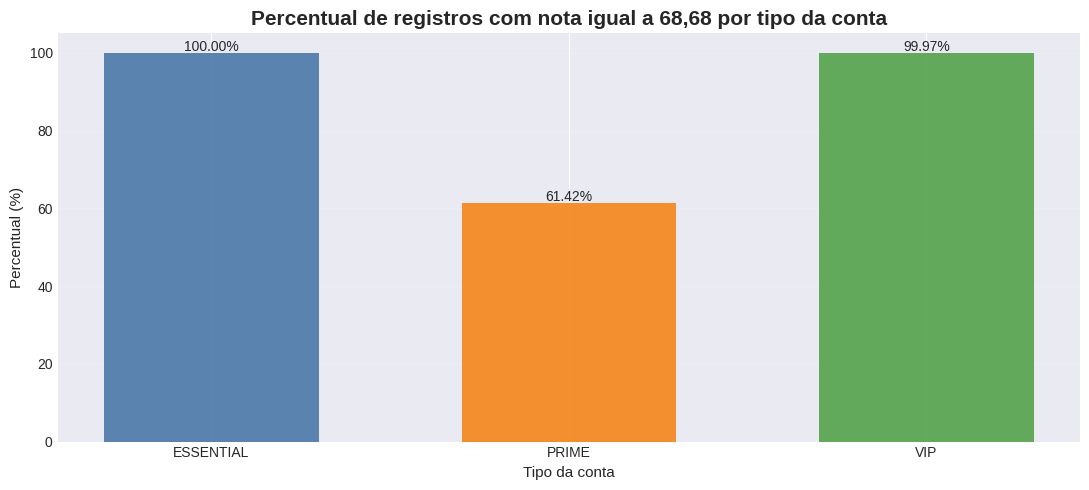

In [52]:
df_conc = resultado["dados_limpos"].copy()

concentracao = (
    df_conc.assign(igual_6868=df_conc["NOTA DE SATISFAÇÃO (%)"] == 68.68)
    .groupby("TIPO DA CONTA")["igual_6868"]
    .mean()
    .mul(100)
    .reset_index(name="percentual_68_68")
)

plt.figure(figsize=(11, 5))

bars = plt.bar(
    concentracao["TIPO DA CONTA"],
    concentracao["percentual_68_68"],
    color=["#4C78A8", "#F58518", "#54A24B"],
    alpha=0.90,
    width=0.6,
)

for bar in bars:
    altura = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        altura + 0.4,
        f"{altura:.2f}%",
        ha="center",
        fontsize=10,
    )

plt.title("Percentual de registros com nota igual a 68,68 por tipo da conta", fontsize=15, fontweight="bold")
plt.xlabel("Tipo da conta", fontsize=11)
plt.ylabel("Percentual (%)", fontsize=11)
plt.grid(axis="y", alpha=0.18)
plt.tight_layout()
sns.despine()
plt.show()


O teste de comparação entre médias indicou evidência estatisticamente significativa de diferença entre os grupos de `TIPO DA CONTA` para a variável `NOTA DE SATISFAÇÃO (%)`, com `p < 0,001`. Como o teste de Levene apontou heterogeneidade de variâncias, adotou-se a `ANOVA de Welch`, procedimento mais adequado para esse cenário. Assim, rejeita-se a hipótese nula de igualdade entre as médias dos grupos.

As estatísticas descritivas mostraram comportamentos distintos entre as categorias. O grupo `ESSENTIAL` apresentou distribuição praticamente constante em `68,68`, enquanto `VIP` manteve valores muito próximos desse nível, com baixa dispersão. Já o grupo `PRIME` apresentou média superior (`70,30`) e variabilidade consideravelmente maior, com intervalo interquartil de `2,42`, indicando distribuição mais espalhada.

Os testes pós-hoc com correção de Holm mostraram que todas as comparações par-a-par foram estatisticamente significativas, evidenciando diferenças entre `ESSENTIAL`, `VIP` e `PRIME`. O tamanho de efeito estimado (`η² ≈ 0,0545`) sugere efeito pequeno, porém não desprezível, indicando que o tipo da conta exerce influência real sobre a nota de satisfação, ainda que com magnitude moderada do ponto de vista prático.

Dessa forma, conclui-se que a média da `NOTA DE SATISFAÇÃO (%)` difere entre os tipos de conta, com destaque para o grupo `PRIME`, que apresentou os níveis mais elevados de satisfação e maior dispersão em comparação aos demais grupos.


##Atividade A2 ([Link](https://colab.research.google.com/drive/1w-72bl_qBnGIR8y9zcGYNcpar9b2JdwA?usp=sharing)): Estatística descritiva



Nesta etapa são analisadas as variáveis quantitativas e qualitativas com o objetivo de compreender a estrutura da base de dados, identificar padrões, dispersões e possíveis assimetrias.

Essa análise fornece contexto interpretativo para os testes estatísticos realizados anteriormente.


### Atividade A2.1: Análise das variáveis quantitativas

Nesta etapa, são analisadas as variáveis quantitativas da base com o objetivo de descrever sua tendência central, dispersão, forma da distribuição e presença de valores extremos. Essa análise oferece suporte à interpretação estatística da base e complementa os testes realizados anteriormente.


In [53]:
# Funções auxiliares

def calcular_resumo_quantitativo(serie, nome_variavel):
    serie = pd.to_numeric(serie, errors="coerce").dropna()

    if len(serie) == 0:
        return None

    media = float(serie.mean())
    mediana = float(serie.median())
    dp = float(serie.std(ddof=1)) if len(serie) > 1 else 0.0
    minimo = float(serie.min())
    maximo = float(serie.max())

    q1 = float(serie.quantile(0.25))
    q3 = float(serie.quantile(0.75))
    iqr = float(q3 - q1)

    p1 = float(serie.quantile(0.01))
    p5 = float(serie.quantile(0.05))
    p95 = float(serie.quantile(0.95))
    p99 = float(serie.quantile(0.99))

    assimetria = float(serie.skew()) if len(serie) > 2 else np.nan
    curtose = float(serie.kurtosis()) if len(serie) > 3 else np.nan
    cv = float(dp / media) if media != 0 else np.nan

    lim_inf = float(q1 - 1.5 * iqr)
    lim_sup = float(q3 + 1.5 * iqr)
    outliers_qtd = int(((serie < lim_inf) | (serie > lim_sup)).sum())
    outliers_perc = float((outliers_qtd / len(serie)) * 100)

    return {
        "variavel": nome_variavel,
        "n": int(len(serie)),
        "media": media,
        "mediana": mediana,
        "dp": dp,
        "min": minimo,
        "max": maximo,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "p1": p1,
        "p5": p5,
        "p95": p95,
        "p99": p99,
        "assimetria": assimetria,
        "curtose": curtose,
        "coef_var": cv,
        "lim_inf_iqr": lim_inf,
        "lim_sup_iqr": lim_sup,
        "outliers_qtd": outliers_qtd,
        "outliers_%": outliers_perc,
    }


In [65]:
# Função principal

def AtividadeA2_1():
    df = table.select_dtypes(include=["int64", "float64"]).dropna(axis=1, how="all").copy()

    resultados = []

    for coluna in df.columns:
        resumo = calcular_resumo_quantitativo(df[coluna], coluna)
        if resumo is not None:
            resultados.append(resumo)

    tabela_resumo = pd.DataFrame(resultados)

    RESULTADOS["A2.1"] = {
        "n_registros": int(len(df)),
        "qtd_variaveis": int(df.shape[1]),
        "tabela_resumo": tabela_resumo,
    }

    print("Análise das variáveis quantitativas concluída.")



In [66]:
AtividadeA2_1()
resultado = RESULTADOS["A2.1"]
tabela_quant = resultado["tabela_resumo"].copy()


Análise das variáveis quantitativas concluída.


In [67]:
colunas_visuais = [
    "variavel", "n", "media", "mediana", "dp", "q1", "q3",
    "iqr", "assimetria", "curtose", "coef_var", "outliers_%"
]

tabela_exibicao = tabela_quant[colunas_visuais].copy()
tabela_exibicao[["media", "mediana", "dp", "q1", "q3", "iqr", "assimetria", "curtose", "coef_var", "outliers_%"]] = (
    tabela_exibicao[["media", "mediana", "dp", "q1", "q3", "iqr", "assimetria", "curtose", "coef_var", "outliers_%"]].round(4)
)

display(tabela_exibicao)



,variavel,n,media,mediana,dp,q1,q3,iqr,assimetria,curtose,coef_var,outliers_%
0,NOTA FISCAL,1120000,5.003551e+06,5.004559e+06,2.309364e+06,3.004136e+06,7.004358e+06,4.000222e+06,-0.0006,-1.2008,0.4615,0.0000
1,DEPENDENTES,1120000,1.059700e+00,1.000000e+00,9.570000e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.1788,1.3475,0.9030,9.9892
2,RENDA BRUTO (R$),1120000,7.722335e+03,3.365220e+03,6.639554e+03,3.240670e+03,8.069252e+03,4.828583e+03,1.4110,0.6259,0.8598,17.3903
3,NOTA DE SATISFAÇÃO (%),1120000,6.896950e+01,6.868000e+01,1.356600e+00,6.868000e+01,6.868000e+01,0.000000e+00,5.9103,40.2667,0.0197,6.8826
4,MEAN: alcohol,1120000,1.300160e+01,1.300150e+01,8.096000e-01,1.245510e+01,1.354820e+01,1.093100e+00,-0.0002,-0.0041,0.0623,0.6843
5,MEAN: malic_acid,1120000,2.335300e+00,2.336400e+00,1.114100e+00,1.584800e+00,3.086200e+00,1.501300e+00,-0.0044,0.0025,0.4771,0.7065
6,MEAN: ash,1120000,2.366500e+00,2.366600e+00,2.737000e-01,2.181800e+00,2.550900e+00,3.691000e-01,-0.0030,0.0047,0.1157,0.7028
7,MEAN: alcalinity_of_ash,1120000,1.949480e+01,1.949560e+01,3.334300e+00,1.724720e+01,2.174080e+01,4.493600e+00,-0.0008,0.0003,0.1710,0.7038
8,MEAN: magnesium,1120000,9.976070e+01,9.975260e+01,1.424360e+01,9.015000e+01,1.093708e+02,1.922090e+01,0.0013,-0.0025,0.1428,0.6879
9,MEAN: total_phenols,1120000,2.295800e+00,2.296400e+00,6.242000e-01,1.875000e+00,2.717600e+00,8.426000e-01,-0.0051,0.0054,0.2719,0.7040


In [69]:
maior_cv = tabela_quant.sort_values("coef_var", ascending=False).head(5)
maior_outliers = tabela_quant.sort_values("outliers_%", ascending=False).head(5)
maior_assimetria = tabela_quant.reindex(
    tabela_quant["assimetria"].abs().sort_values(ascending=False).index
).head(5)
display(maior_cv[["variavel", "coef_var"]].round(4))
display(maior_outliers[["variavel", "outliers_%"]].round(4))
display(maior_assimetria[["variavel", "assimetria"]].round(4))


,variavel,coef_var
17,TOTAL (R$),1.0011
1,DEPENDENTES,0.9030
2,RENDA BRUTO (R$),0.8598
10,MEAN: flavanoids,0.4910
5,MEAN: malic_acid,0.4771


,variavel,outliers_%
2,RENDA BRUTO (R$),17.3903
1,DEPENDENTES,9.9892
17,TOTAL (R$),9.5449
3,NOTA DE SATISFAÇÃO (%),6.8826
5,MEAN: malic_acid,0.7065


,variavel,assimetria
3,NOTA DE SATISFAÇÃO (%),5.9103
17,TOTAL (R$),1.9738
2,RENDA BRUTO (R$),1.4110
1,DEPENDENTES,1.1788
16,MEAN: proline,-0.0071


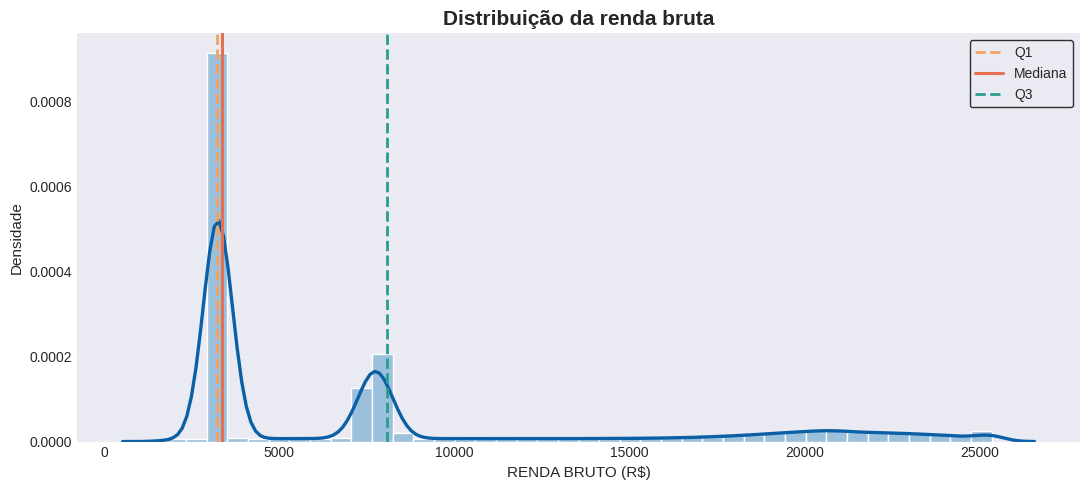

In [70]:
serie = table["RENDA BRUTO (R$)"].dropna()
cap = serie.quantile(0.99)
serie_plot = serie.clip(upper=cap)

q1 = serie.quantile(0.25)
mediana = serie.median()
q3 = serie.quantile(0.75)

plt.figure(figsize=(11, 5))

sns.histplot(
    serie_plot,
    bins=40,
    stat="density",
    color="#7FB3D5",
    edgecolor="white",
    alpha=0.75,
)

sns.kdeplot(
    serie_plot,
    color="#0B5FA5",
    linewidth=2.4,
)

plt.axvline(q1, color="#F4A261", linestyle="--", linewidth=2, label="Q1")
plt.axvline(mediana, color="#E76F51", linestyle="-", linewidth=2.2, label="Mediana")
plt.axvline(q3, color="#2A9D8F", linestyle="--", linewidth=2, label="Q3")

plt.title("Distribuição da renda bruta", fontsize=15, fontweight="bold")
plt.xlabel("RENDA BRUTO (R$)", fontsize=11)
plt.ylabel("Densidade", fontsize=11)
plt.grid(alpha=0.18)
plt.legend(frameon=True, edgecolor="black")
plt.tight_layout()
sns.despine()
plt.show()


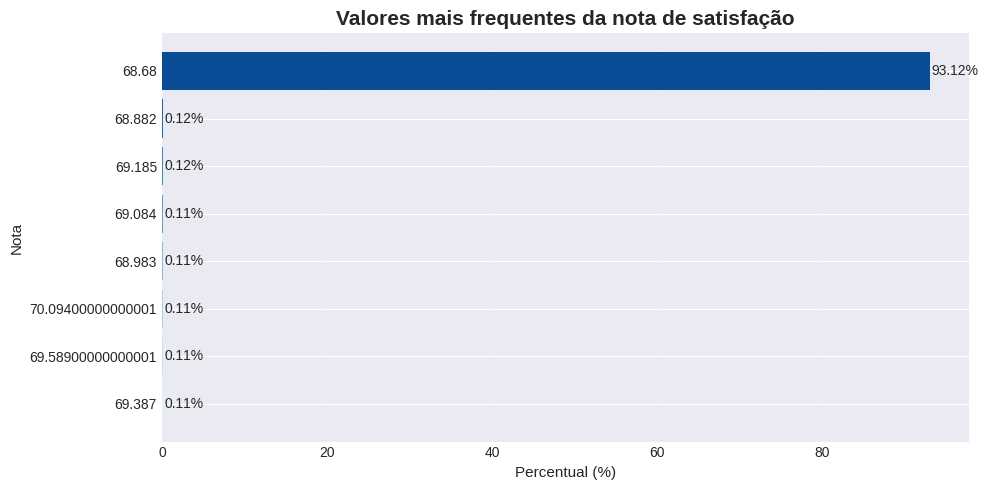

In [71]:
serie = table["NOTA DE SATISFAÇÃO (%)"].dropna()
top_valores = (serie.value_counts(normalize=True).head(8) * 100).sort_values()

plt.figure(figsize=(10, 5))

bars = plt.barh(
    top_valores.index.astype(str),
    top_valores.values,
    color=sns.color_palette("Blues", len(top_valores))
)

for bar in bars:
    largura = bar.get_width()
    plt.text(
        largura + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{largura:.2f}%",
        va="center",
        fontsize=10,
    )

plt.title("Valores mais frequentes da nota de satisfação", fontsize=15, fontweight="bold")
plt.xlabel("Percentual (%)", fontsize=11)
plt.ylabel("Nota", fontsize=11)
plt.grid(axis="x", alpha=0.18)
plt.tight_layout()
sns.despine()
plt.show()


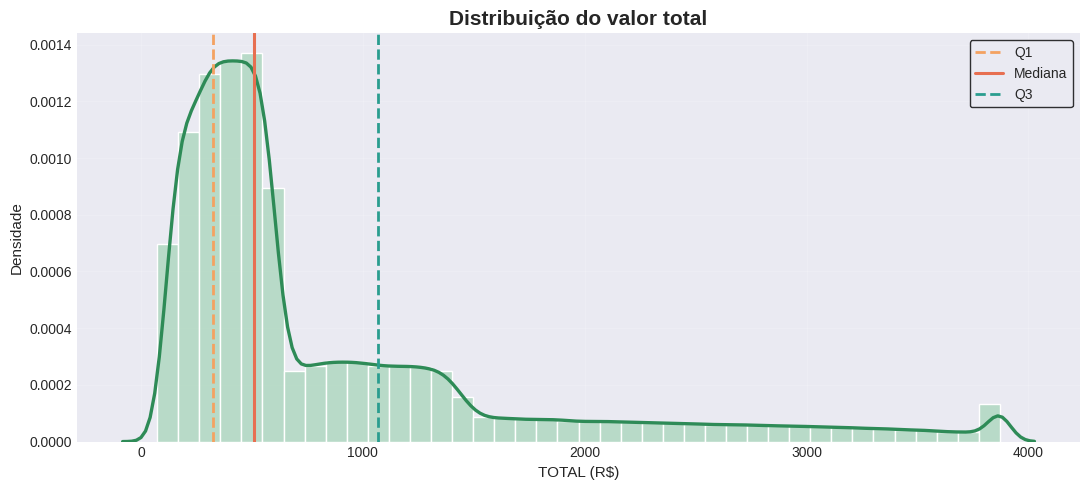

In [72]:
serie = table["TOTAL (R$)"].dropna()
cap = serie.quantile(0.99)
serie_plot = serie.clip(upper=cap)

q1 = serie.quantile(0.25)
mediana = serie.median()
q3 = serie.quantile(0.75)

plt.figure(figsize=(11, 5))

sns.histplot(
    serie_plot,
    bins=40,
    stat="density",
    color="#A8D5BA",
    edgecolor="white",
    alpha=0.75,
)

sns.kdeplot(
    serie_plot,
    color="#2E8B57",
    linewidth=2.4,
)

plt.axvline(q1, color="#F4A261", linestyle="--", linewidth=2, label="Q1")
plt.axvline(mediana, color="#E76F51", linestyle="-", linewidth=2.2, label="Mediana")
plt.axvline(q3, color="#2A9D8F", linestyle="--", linewidth=2, label="Q3")

plt.title("Distribuição do valor total", fontsize=15, fontweight="bold")
plt.xlabel("TOTAL (R$)", fontsize=11)
plt.ylabel("Densidade", fontsize=11)
plt.grid(alpha=0.18)
plt.legend(frameon=True, edgecolor="black")
plt.tight_layout()
sns.despine()
plt.show()


A análise das variáveis quantitativas evidenciou comportamentos distintos em termos de dispersão, concentração e assimetria entre os indicadores numéricos da base. Em relação à variabilidade relativa, destacou-se a variável `TOTAL (R$)`, que apresentou o maior coeficiente de variação (`1,0011`), indicando elevada heterogeneidade proporcional em relação à média.

No critério de outliers pelo intervalo interquartil, a variável `RENDA BRUTO (R$)` apresentou a maior incidência de valores extremos (`17,39%`), seguida por `DEPENDENTES` (`9,99%`) e `TOTAL (R$)` (`9,54%`). Esse resultado sugere a presença de caudas longas e reforça a necessidade de cautela na interpretação de medidas como média e desvio-padrão, especialmente nas variáveis de natureza monetária.

Quanto à forma da distribuição, a variável `NOTA DE SATISFAÇÃO (%)` apresentou a maior assimetria (`5,9103`), refletindo forte concentração em torno do valor `68,68`, que corresponde a `93,12%` dos registros. As variáveis `TOTAL (R$)` (`1,9738`) e `RENDA BRUTO (R$)` (`1,4110`) também exibiram assimetria positiva relevante, indicando distribuições com cauda à direita e afastamento da simetria.

De modo geral, os resultados descritivos e visuais mostram que as variáveis quantitativas não apresentam comportamento homogêneo, havendo diferenças importantes de dispersão, presença de extremos e concentração de valores. Esse diagnóstico complementa as análises anteriores e fornece base interpretativa importante para a escolha e a leitura dos testes estatísticos aplicados ao longo do estudo.


### Atividade A2.2: Análise das variáveis qualitativas

Nesta etapa, são analisadas as variáveis qualitativas da base com o objetivo de identificar frequência das categorias, concentração, cardinalidade e possíveis padrões de distribuição. Essa análise complementa a leitura estatística da base e contribui para a compreensão do perfil dos registros observados.



In [73]:
def resumir_variavel_qualitativa(serie, n_total, top_n=10):
    serie = serie.astype("string").str.strip()

    missing_mask = serie.isna() | (serie == "") | (serie.str.lower() == "nan")
    missing_qtd = int(missing_mask.sum())
    missing_pct = float((missing_qtd / n_total) * 100)

    serie_valid = serie[~missing_mask]
    n_validos = int(len(serie_valid))

    if n_validos == 0:
        return {
            "resumo": {
                "n_total": int(n_total),
                "n_validos": 0,
                "missing_qtd": missing_qtd,
                "missing_%": missing_pct,
                "categorias_unicas": 0,
                "moda": None,
                "moda_qtd": 0,
                "moda_%_validos": 0.0,
                "top1_%_validos": 0.0,
                "top3_%_validos": 0.0,
                "top5_%_validos": 0.0,
                "diversidade": "sem dados",
            },
            "top_table": pd.DataFrame(columns=["categoria", "freq_abs", "freq_%"]),
        }

    freq_abs = serie_valid.value_counts()
    freq_rel = (freq_abs / n_validos) * 100

    moda = str(freq_abs.index[0])
    moda_qtd = int(freq_abs.iloc[0])
    moda_pct = float(freq_rel.iloc[0])

    top1 = float(freq_rel.iloc[:1].sum())
    top3 = float(freq_rel.iloc[:3].sum())
    top5 = float(freq_rel.iloc[:5].sum())

    if top1 >= 70:
        diversidade = "alta concentração"
    elif top1 >= 40:
        diversidade = "concentração moderada"
    else:
        diversidade = "distribuição mais equilibrada"

    top_table = pd.DataFrame({
        "categoria": freq_abs.index.astype("string")[:top_n],
        "freq_abs": freq_abs.values[:top_n],
        "freq_%": freq_rel.values[:top_n],
    })

    resumo = {
        "n_total": int(n_total),
        "n_validos": n_validos,
        "missing_qtd": missing_qtd,
        "missing_%": missing_pct,
        "categorias_unicas": int(freq_abs.shape[0]),
        "moda": moda,
        "moda_qtd": moda_qtd,
        "moda_%_validos": moda_pct,
        "top1_%_validos": top1,
        "top3_%_validos": top3,
        "top5_%_validos": top5,
        "diversidade": diversidade,
    }

    return {"resumo": resumo, "top_table": top_table}


In [74]:
def AtividadeA2_2():
    df = table.copy()
    n_total = int(len(df))

    cat_df = df.select_dtypes(include=["object", "category", "bool"]).copy()

    heuristicas = []
    for coluna in df.columns:
        if coluna in cat_df.columns:
            continue

        if pd.api.types.is_integer_dtype(df[coluna]) or pd.api.types.is_float_dtype(df[coluna]):
            serie_tmp = df[coluna].dropna()
            if len(serie_tmp) == 0:
                continue

            nunique = int(serie_tmp.nunique())
            if 1 < nunique <= 12:
                heuristicas.append(coluna)

    for coluna in heuristicas:
        cat_df[coluna] = df[coluna].astype("Int64").astype("string")

    resultados = {}
    linhas_resumo = []

    for coluna in cat_df.columns:
        saida = resumir_variavel_qualitativa(cat_df[coluna], n_total=n_total, top_n=10)

        resultados[coluna] = {
            "resumo": saida["resumo"],
            "top_categorias": saida["top_table"],
        }

        linhas_resumo.append({
            "variavel": coluna,
            **saida["resumo"],
        })

    tabela_resumo = pd.DataFrame(linhas_resumo)

    RESULTADOS["A2.2"] = {
        "variaveis": list(cat_df.columns),
        "variaveis_heuristicas": heuristicas,
        "resumo_por_variavel": resultados,
        "tabela_resumo": tabela_resumo,
    }

    print("Análise das variáveis qualitativas concluída.")
    print(f"Registros analisados: {n_total:,}")
    print(f"Variáveis qualitativas: {cat_df.shape[1]}")


In [75]:
AtividadeA2_2()

resultado = RESULTADOS["A2.2"]
tabela_qualitativas = resultado["tabela_resumo"].copy()


Análise das variáveis qualitativas concluída.
Registros analisados: 1,120,000
Variáveis qualitativas: 6


In [82]:
tabela_qualitativas = resultado["tabela_resumo"].copy()

colunas_visuais = [
    "variavel",
    "missing_%",
    "categorias_unicas",
    "moda",
    "moda_%_validos",
    "top1_%_validos",
    "top3_%_validos",
    "top5_%_validos",
    "diversidade",
]

tabela_exibicao = tabela_qualitativas[colunas_visuais].copy()
tabela_exibicao[["missing_%", "moda_%_validos", "top1_%_validos", "top3_%_validos", "top5_%_validos"]] = (
    tabela_exibicao[["missing_%", "moda_%_validos", "top1_%_validos", "top3_%_validos", "top5_%_validos"]].round(2)
)

display(tabela_exibicao)


,variavel,missing_%,categorias_unicas,moda,moda_%_validos,top1_%_validos,top3_%_validos,top5_%_validos,diversidade
0,REGIÃO,0.0,5,SUDESTE,67.05,67.05,92.03,100.0,concentração moderada
1,SEXO,0.0,2,MASCULINO,86.95,86.95,100.00,100.0,alta concentração
2,ESTADO CIVIL,0.0,3,CASADO,54.98,54.98,100.00,100.0,concentração moderada
3,OPINIÃO DO CLIENTE,0.0,25,Entrega foi boa e rápida na UVVine,15.43,15.43,46.25,77.0,distribuição mais equilibrada
4,TIPO DA CONTA,0.0,3,ESSENTIAL,58.05,58.05,100.00,100.0,concentração moderada
5,DEPENDENTES,0.0,5,1,52.99,52.99,90.01,100.0,concentração moderada


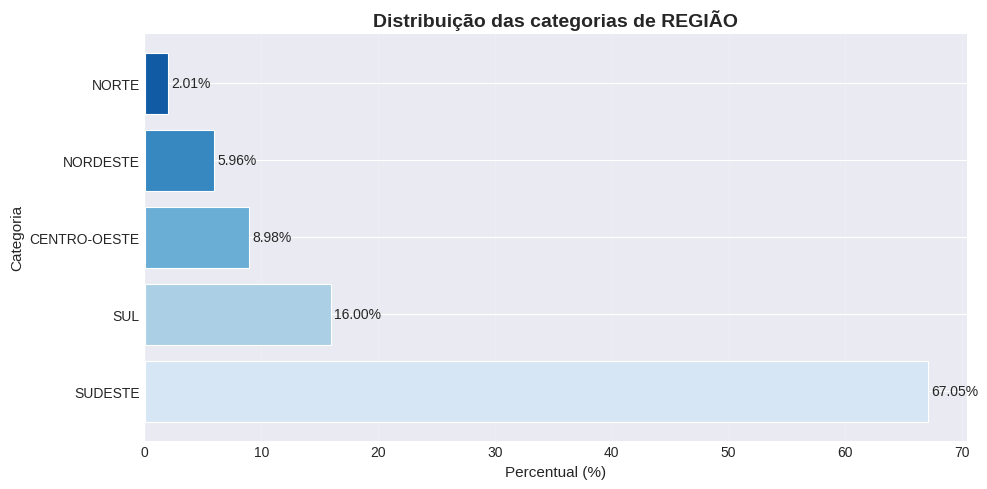

In [83]:
top_table = resultado["resumo_por_variavel"]["REGIÃO"]["top_categorias"].copy()

plt.figure(figsize=(10, 5))

bars = plt.barh(
    top_table["categoria"],
    top_table["freq_%"],
    color=sns.color_palette("Blues", len(top_table)),
    edgecolor="white",
    linewidth=0.8,
)

for bar, valor in zip(bars, top_table["freq_%"]):
    plt.text(
        bar.get_width() + 0.25,
        bar.get_y() + bar.get_height() / 2,
        f"{valor:.2f}%",
        va="center",
        fontsize=10,
    )

plt.title("Distribuição das categorias de REGIÃO", fontsize=14, fontweight="bold")
plt.xlabel("Percentual (%)", fontsize=11)
plt.ylabel("Categoria", fontsize=11)
plt.grid(axis="x", alpha=0.18)
plt.tight_layout()
sns.despine()
plt.show()


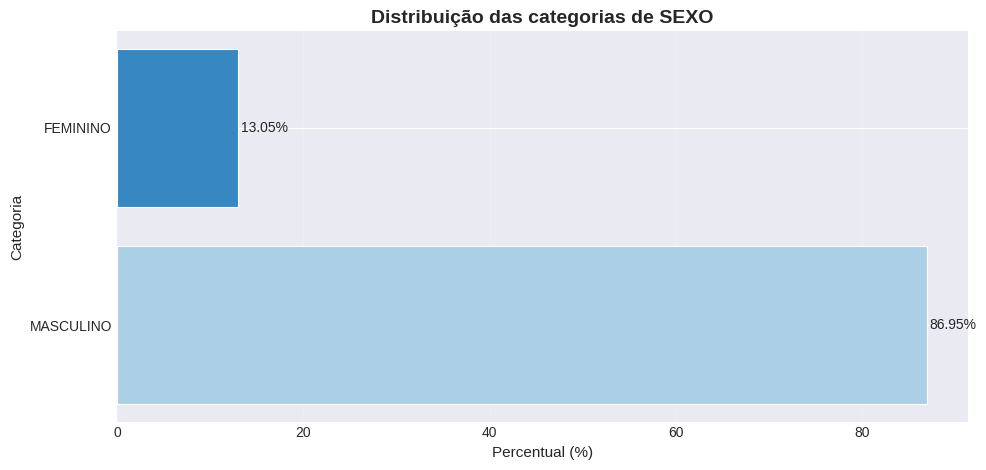

In [84]:
top_table = resultado["resumo_por_variavel"]["SEXO"]["top_categorias"].copy()

plt.figure(figsize=(10, 4.8))

bars = plt.barh(
    top_table["categoria"],
    top_table["freq_%"],
    color=sns.color_palette("Blues", len(top_table)),
    edgecolor="white",
    linewidth=0.8,
)

for bar, valor in zip(bars, top_table["freq_%"]):
    plt.text(
        bar.get_width() + 0.25,
        bar.get_y() + bar.get_height() / 2,
        f"{valor:.2f}%",
        va="center",
        fontsize=10,
    )

plt.title("Distribuição das categorias de SEXO", fontsize=14, fontweight="bold")
plt.xlabel("Percentual (%)", fontsize=11)
plt.ylabel("Categoria", fontsize=11)
plt.grid(axis="x", alpha=0.18)
plt.tight_layout()
sns.despine()
plt.show()


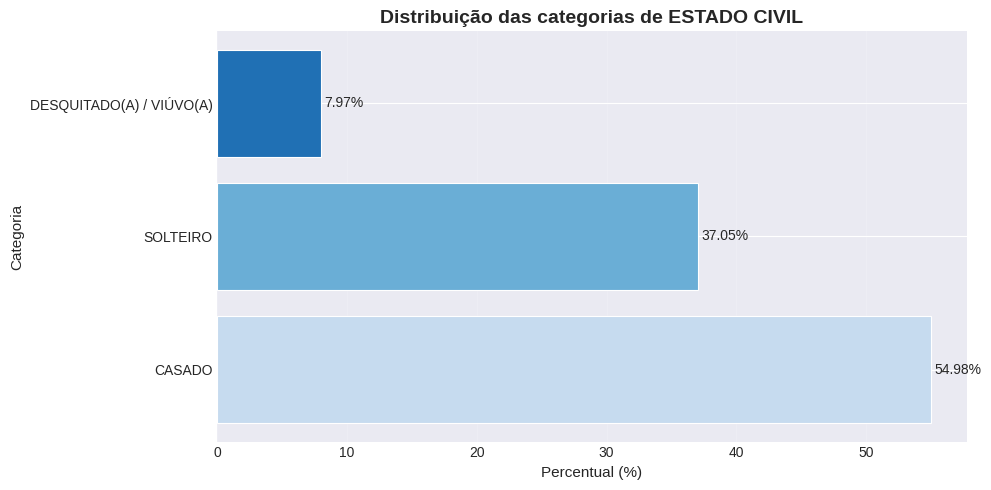

In [85]:
top_table = resultado["resumo_por_variavel"]["ESTADO CIVIL"]["top_categorias"].copy()

plt.figure(figsize=(10, 5))

bars = plt.barh(
    top_table["categoria"],
    top_table["freq_%"],
    color=sns.color_palette("Blues", len(top_table)),
    edgecolor="white",
    linewidth=0.8,
)

for bar, valor in zip(bars, top_table["freq_%"]):
    plt.text(
        bar.get_width() + 0.25,
        bar.get_y() + bar.get_height() / 2,
        f"{valor:.2f}%",
        va="center",
        fontsize=10,
    )

plt.title("Distribuição das categorias de ESTADO CIVIL", fontsize=14, fontweight="bold")
plt.xlabel("Percentual (%)", fontsize=11)
plt.ylabel("Categoria", fontsize=11)
plt.grid(axis="x", alpha=0.18)
plt.tight_layout()
sns.despine()
plt.show()


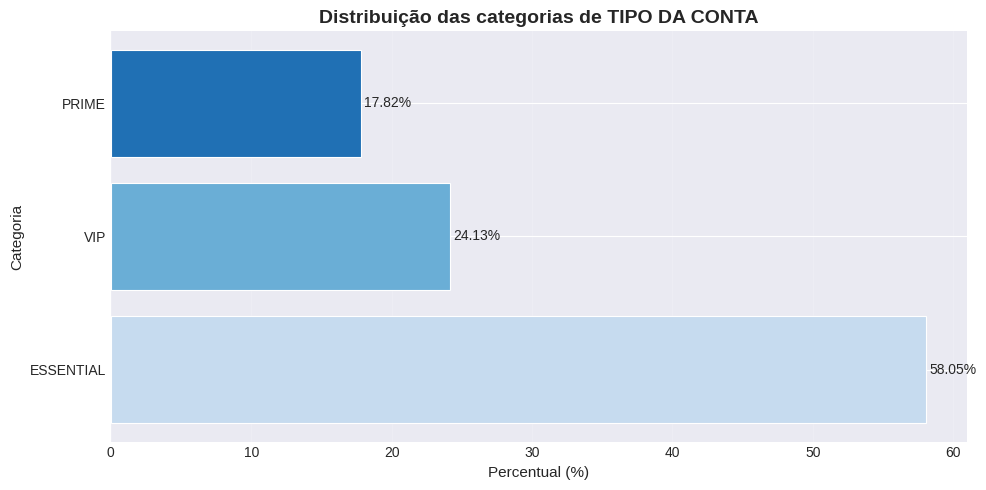

In [86]:
top_table = resultado["resumo_por_variavel"]["TIPO DA CONTA"]["top_categorias"].copy()

plt.figure(figsize=(10, 5))

bars = plt.barh(
    top_table["categoria"],
    top_table["freq_%"],
    color=sns.color_palette("Blues", len(top_table)),
    edgecolor="white",
    linewidth=0.8,
)

for bar, valor in zip(bars, top_table["freq_%"]):
    plt.text(
        bar.get_width() + 0.25,
        bar.get_y() + bar.get_height() / 2,
        f"{valor:.2f}%",
        va="center",
        fontsize=10,
    )

plt.title("Distribuição das categorias de TIPO DA CONTA", fontsize=14, fontweight="bold")
plt.xlabel("Percentual (%)", fontsize=11)
plt.ylabel("Categoria", fontsize=11)
plt.grid(axis="x", alpha=0.18)
plt.tight_layout()
sns.despine()
plt.show()


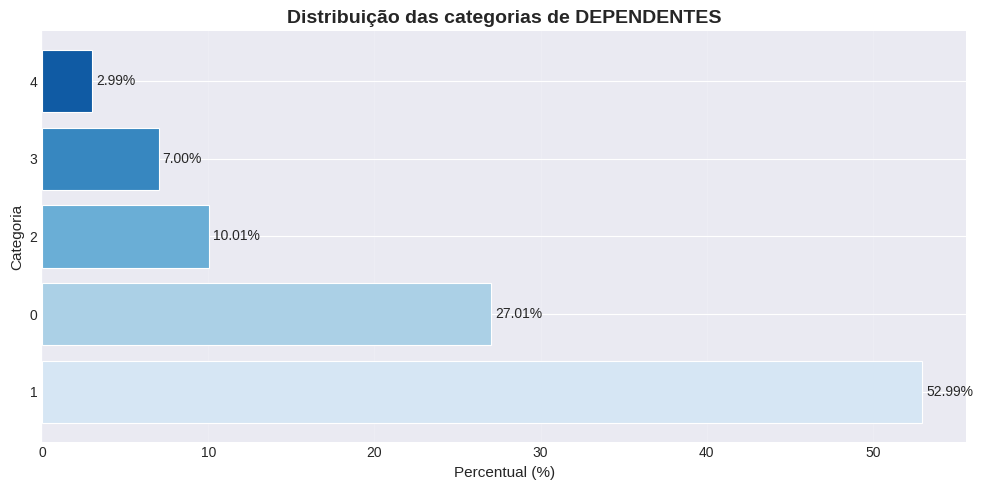

In [87]:
top_table = resultado["resumo_por_variavel"]["DEPENDENTES"]["top_categorias"].copy()

plt.figure(figsize=(10, 5))

bars = plt.barh(
    top_table["categoria"].astype(str),
    top_table["freq_%"],
    color=sns.color_palette("Blues", len(top_table)),
    edgecolor="white",
    linewidth=0.8,
)

for bar, valor in zip(bars, top_table["freq_%"]):
    plt.text(
        bar.get_width() + 0.25,
        bar.get_y() + bar.get_height() / 2,
        f"{valor:.2f}%",
        va="center",
        fontsize=10,
    )

plt.title("Distribuição das categorias de DEPENDENTES", fontsize=14, fontweight="bold")
plt.xlabel("Percentual (%)", fontsize=11)
plt.ylabel("Categoria", fontsize=11)
plt.grid(axis="x", alpha=0.18)
plt.tight_layout()
sns.despine()
plt.show()


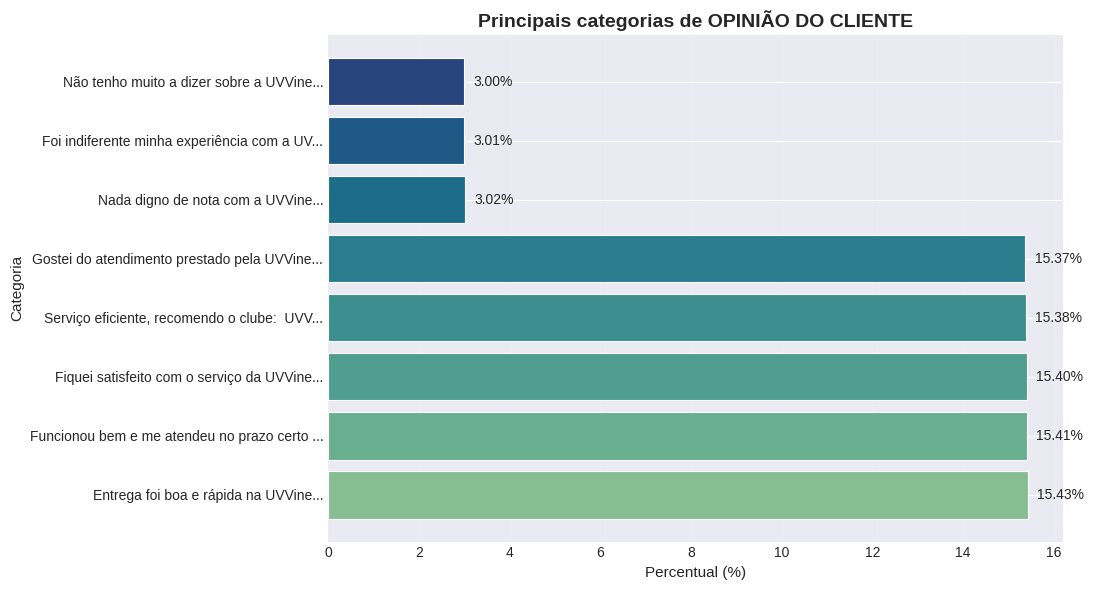

In [88]:
top_table = resultado["resumo_por_variavel"]["OPINIÃO DO CLIENTE"]["top_categorias"].copy().head(8)
top_table["categoria_curta"] = top_table["categoria"].str.slice(0, 42) + "..."

plt.figure(figsize=(11, 6))

bars = plt.barh(
    top_table["categoria_curta"],
    top_table["freq_%"],
    color=sns.color_palette("crest", len(top_table)),
    edgecolor="white",
    linewidth=0.8,
)

for bar, valor in zip(bars, top_table["freq_%"]):
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{valor:.2f}%",
        va="center",
        fontsize=10,
    )

plt.title("Principais categorias de OPINIÃO DO CLIENTE", fontsize=14, fontweight="bold")
plt.xlabel("Percentual (%)", fontsize=11)
plt.ylabel("Categoria", fontsize=11)
plt.grid(axis="x", alpha=0.18)
plt.tight_layout()
sns.despine()
plt.show()


A análise das variáveis qualitativas mostrou ausência de valores ausentes nas categorias avaliadas, o que favorece a consistência descritiva desta etapa. Em termos de concentração, a variável `SEXO` apresentou o padrão mais dominante, com `86,95%` dos registros classificados como `MASCULINO`, caracterizando alta concentração e baixa variabilidade categórica.

As variáveis `REGIÃO`, `ESTADO CIVIL`, `TIPO DA CONTA` e `DEPENDENTES` apresentaram concentração moderada, com predominância clara de uma categoria principal. Destacam-se, respectivamente, `SUDESTE` em `REGIÃO` (`67,05%`), `CASADO` em `ESTADO CIVIL` (`54,98%`), `ESSENTIAL` em `TIPO DA CONTA` (`58,05%`) e `1` em `DEPENDENTES` (`52,99%`).

Por outro lado, a variável `OPINIÃO DO CLIENTE` apresentou a maior diversidade categórica, com `25` categorias distintas e categoria modal de `15,43%`, o que indica distribuição mais equilibrada em comparação às demais variáveis qualitativas. Ainda assim, as cinco categorias mais frequentes concentram `77,00%` das respostas, sugerindo diversidade com predominância parcial de alguns padrões de opinião.

De modo geral, os resultados indicam que as variáveis qualitativas da base combinam estruturas mais concentradas, como `SEXO`, com variáveis mais diversificadas, como `OPINIÃO DO CLIENTE`. Esse diagnóstico contribui para caracterizar o perfil dos registros e complementa a interpretação estatística das etapas subsequentes do estudo.


##Atividade A3: Resultado da Pesquisa de Satisfação


Nesta etapa é realizada a consolidação da percepção dos clientes por meio da discretização da opinião, cálculo de percentuais e estimativa de intervalo de confiança via Bootstrap.

O objetivo é fornecer indicadores claros de satisfação geral e segmentada, apoiando decisões estratégicas da UVVine.






Fazer o resultado da Pesquisa de satisfação do cliente em porcentagem (%):
* Geral
* Por Sexo

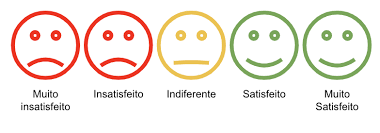

###Atividade A3.1: Discretizar a Variável Qualitativa (OPINIÃO DO CLIENTE)

Nesta etapa, a variável `OPINIÃO DO CLIENTE` é transformada em um indicador binário de satisfação, permitindo estimar o percentual de clientes satisfeitos na base total e por sexo. Além disso, utiliza-se bootstrap para construir um intervalo de confiança de 95% para a satisfação geral.


In [89]:
def AtividadeA3_1(B=3000, seed=42):
    col_op = "OPINIÃO DO CLIENTE"
    col_sexo = "SEXO"

    df = table.copy()

    def classificar_sentimento(texto):
        if pd.isna(texto):
            return np.nan

        t = str(texto).upper().strip()

        positivas = [
            "EXCELENTE", "ÓTIMO", "OTIMO", "PERFEITO", "IMPECÁVEL", "IMPECAVEL",
            "SUPEROU", "ADOREI", "GOSTEI", "RECOMENDO", "SATISFEITO", "SATISFEITA",
            "BOA", "BOM", "EFICIENTE", "TOP", "MARAVILHOSAMENTE"
        ]

        neutras = [
            "INDIFERENTE", "NEUTRA", "NEUTRO", "SEM OPINIÃO", "SEM OPINIAO",
            "NÃO TENHO", "NAO TENHO", "COMUM", "REGULAR", "ACEITAVEL", "ACEITÁVEL",
            "RAZOÁVEL", "RAZOAVEL"
        ]

        negativas = [
            "NADA DIGNO", "NÃO ATENDEU", "NAO ATENDEU", "PODERIA MELHORAR",
            "ESPERAVA MAIS", "NAO GOSTEI", "NÃO GOSTEI", "RUIM", "PÉSSIMO", "PESSIMO"
        ]

        if any(p in t for p in positivas):
            return 1
        if any(n in t for n in negativas):
            return 0
        if any(n in t for n in neutras):
            return 0

        return 0

    df["SATISFEITO_BIN"] = df[col_op].apply(classificar_sentimento)
    df_valid = df.dropna(subset=["SATISFEITO_BIN"]).copy()

    n_valido = int(len(df_valid))
    if n_valido == 0:
        raise ValueError("Não há registros válidos para calcular a satisfação.")

    p_hat = float(df_valid["SATISFEITO_BIN"].mean())
    perc_geral = p_hat * 100

    rng = np.random.default_rng(seed)
    boot = (rng.binomial(n=n_valido, p=p_hat, size=B) / n_valido) * 100

    ic_inf = float(np.percentile(boot, 2.5))
    ic_sup = float(np.percentile(boot, 97.5))

    satisfacao_sexo = None
    if col_sexo in df_valid.columns:
        satisfacao_sexo = (
            df_valid.groupby(col_sexo)["SATISFEITO_BIN"]
            .mean()
            .mul(100)
            .sort_values(ascending=False)
        )

    RESULTADOS["A3.1"] = {
        "n_valido": n_valido,
        "satisfacao_geral_%": float(perc_geral),
        "ic95_%": (ic_inf, ic_sup),
        "bootstrap_%": boot,
        "por_sexo_%": satisfacao_sexo.to_dict() if satisfacao_sexo is not None else None,
        "dados_validos": df_valid,
    }

    print("Resultado da pesquisa de satisfação calculado.")


In [90]:
AtividadeA3_1()
resultado = RESULTADOS["A3.1"]


Resultado da pesquisa de satisfação calculado.


In [91]:
resumo_a31 = pd.DataFrame(
    [
        {
            "N válidos": resultado["n_valido"],
            "Satisfação geral (%)": resultado["satisfacao_geral_%"],
            "IC 95% inferior": resultado["ic95_%"][0],
            "IC 95% superior": resultado["ic95_%"][1],
        }
    ]
)

resumo_a31[["Satisfação geral (%)", "IC 95% inferior", "IC 95% superior"]] = (
    resumo_a31[["Satisfação geral (%)", "IC 95% inferior", "IC 95% superior"]].round(2)
)

display(resumo_a31)


,N válidos,Satisfação geral (%),IC 95% inferior,IC 95% superior
0,1120000,64.79,64.7,64.87


In [92]:
if resultado["por_sexo_%"] is not None:
    resumo_sexo = pd.DataFrame(
        list(resultado["por_sexo_%"].items()),
        columns=["SEXO", "Satisfação (%)"]
    )
    resumo_sexo["Satisfação (%)"] = resumo_sexo["Satisfação (%)"].round(2)
    display(resumo_sexo)


,SEXO,Satisfação (%)
0,MASCULINO,64.82
1,FEMININO,64.55


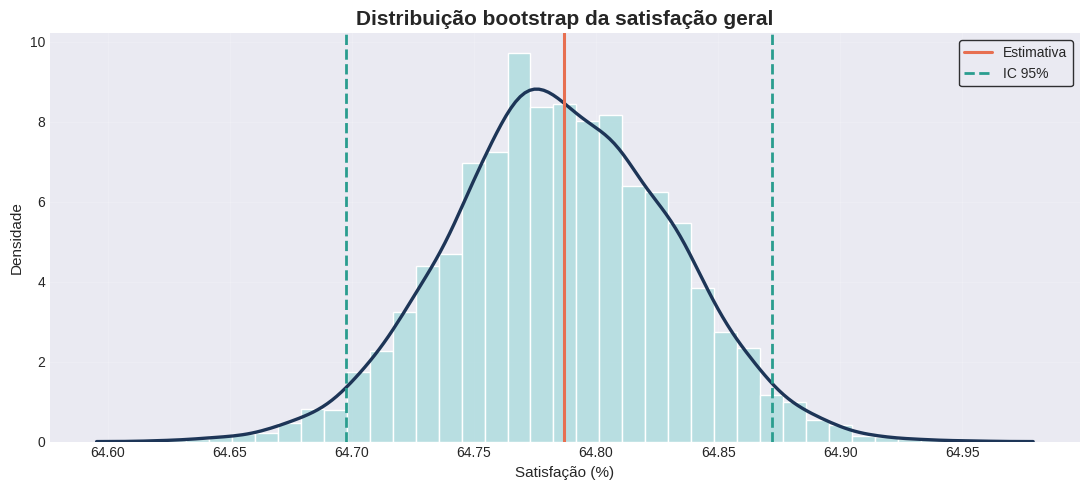

In [93]:
boot = resultado["bootstrap_%"]
estimativa = resultado["satisfacao_geral_%"]
ic_inf, ic_sup = resultado["ic95_%"]

plt.figure(figsize=(11, 5))

sns.histplot(
    boot,
    bins=35,
    stat="density",
    color="#A8DADC",
    edgecolor="white",
    alpha=0.75,
)

sns.kdeplot(
    boot,
    color="#1D3557",
    linewidth=2.4,
)

plt.axvline(estimativa, color="#E76F51", linestyle="-", linewidth=2.2, label="Estimativa")
plt.axvline(ic_inf, color="#2A9D8F", linestyle="--", linewidth=2, label="IC 95%")
plt.axvline(ic_sup, color="#2A9D8F", linestyle="--", linewidth=2)

plt.title("Distribuição bootstrap da satisfação geral", fontsize=15, fontweight="bold")
plt.xlabel("Satisfação (%)", fontsize=11)
plt.ylabel("Densidade", fontsize=11)
plt.grid(alpha=0.18)
plt.legend(frameon=True, edgecolor="black")
plt.tight_layout()
sns.despine()
plt.show()


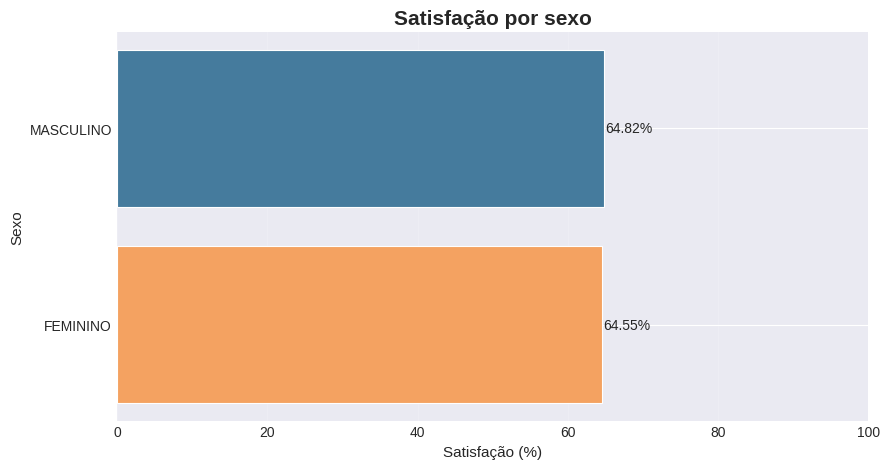

In [94]:
if resultado["por_sexo_%"] is not None:
    resumo_sexo = pd.DataFrame(
        list(resultado["por_sexo_%"].items()),
        columns=["SEXO", "Satisfação (%)"]
    ).sort_values("Satisfação (%)")

    plt.figure(figsize=(9, 4.8))

    bars = plt.barh(
        resumo_sexo["SEXO"],
        resumo_sexo["Satisfação (%)"],
        color=["#F4A261", "#457B9D"][:len(resumo_sexo)],
        edgecolor="white",
        linewidth=0.8,
    )

    for bar, valor in zip(bars, resumo_sexo["Satisfação (%)"]):
        plt.text(
            bar.get_width() + 0.15,
            bar.get_y() + bar.get_height() / 2,
            f"{valor:.2f}%",
            va="center",
            fontsize=10,
        )

    plt.title("Satisfação por sexo", fontsize=15, fontweight="bold")
    plt.xlabel("Satisfação (%)", fontsize=11)
    plt.ylabel("Sexo", fontsize=11)
    plt.xlim(0, 100)
    plt.grid(axis="x", alpha=0.18)
    plt.tight_layout()
    sns.despine()
    plt.show()


A discretização da variável `OPINIÃO DO CLIENTE` permitiu estimar a satisfação geral dos clientes em `64,79%`. O intervalo de confiança de 95% obtido por bootstrap variou de `64,70%` a `64,87%`, indicando baixa variabilidade amostral e boa precisão da estimativa.

Na análise segmentada por sexo, observou-se satisfação de `64,82%` entre os clientes do sexo `MASCULINO` e de `64,55%` entre os do sexo `FEMININO`. A diferença entre os grupos foi pequena, sugerindo comportamento bastante semelhante entre os segmentos analisados.

De modo geral, os resultados indicam predominância de avaliações satisfatórias na base, com estabilidade estatística da estimativa global e pouca diferença entre homens e mulheres. Assim, o indicador construído nesta etapa fornece uma medida objetiva e confiável da percepção dos clientes, servindo de base para a consolidação dos resultados da pesquisa de satisfação nas etapas seguintes do estudo.


### Atividade A3.2: Análise bootstrap do resultado da pesquisa de satisfação

Nesta etapa, aprofunda-se a análise da satisfação dos clientes por meio da técnica bootstrap, com o objetivo de estimar a precisão da satisfação geral, calcular o erro padrão empírico e construir intervalos de confiança. Além disso, avalia-se a diferença de satisfação entre os grupos de sexo, permitindo verificar se há variação relevante entre os segmentos.


In [95]:
def AtividadeA3_2(B=3000, seed=42):
    col_op = "OPINIÃO DO CLIENTE"
    col_sexo = "SEXO"

    df = table.copy()

    def classificar_sentimento(texto):
        if pd.isna(texto):
            return np.nan

        t = str(texto).upper().strip()

        positivas = [
            "EXCELENTE", "ÓTIMO", "OTIMO", "PERFEITO", "IMPECÁVEL", "IMPECAVEL",
            "SUPEROU", "ADOREI", "GOSTEI", "RECOMENDO", "SATISFEITO", "SATISFEITA",
            "BOA", "BOM", "EFICIENTE", "TOP"
        ]

        neutras = [
            "INDIFERENTE", "NEUTRA", "NEUTRO", "SEM OPINIÃO", "SEM OPINIAO",
            "NÃO TENHO", "NAO TENHO", "COMUM", "REGULAR", "ACEITAVEL", "ACEITÁVEL",
            "RAZOÁVEL", "RAZOAVEL"
        ]

        negativas = [
            "NADA DIGNO", "NÃO ATENDEU", "NAO ATENDEU",
            "PODERIA MELHORAR", "ESPERAVA MAIS"
        ]

        if any(p in t for p in positivas):
            return 1
        if any(n in t for n in negativas):
            return 0
        if any(n in t for n in neutras):
            return 0

        return 0

    df["SATISFEITO_BIN"] = df[col_op].apply(classificar_sentimento)
    df_valid = df.dropna(subset=["SATISFEITO_BIN"]).copy()

    n = len(df_valid)
    if n == 0:
        raise ValueError("Nenhum registro válido encontrado para a análise bootstrap.")

    perc_geral = float(df_valid["SATISFEITO_BIN"].mean() * 100)

    rng = np.random.default_rng(seed)
    y = df_valid["SATISFEITO_BIN"].values

    boot = np.empty(B)
    for b in range(B):
        idx = rng.integers(0, n, n)
        boot[b] = y[idx].mean() * 100

    se_boot = float(np.std(boot, ddof=1))
    ic_inf = float(np.percentile(boot, 2.5))
    ic_sup = float(np.percentile(boot, 97.5))

    por_sexo = None
    dif_sexo = None
    ic_dif = None
    p_boot = None
    diff_boot = None

    if col_sexo in df_valid.columns:
        por_sexo = (
            df_valid.groupby(col_sexo)["SATISFEITO_BIN"]
            .mean()
            .mul(100)
            .round(2)
        )

        if {"MASCULINO", "FEMININO"}.issubset(set(por_sexo.index.astype(str))):
            y_m = df_valid.loc[df_valid[col_sexo] == "MASCULINO", "SATISFEITO_BIN"].values
            y_f = df_valid.loc[df_valid[col_sexo] == "FEMININO", "SATISFEITO_BIN"].values

            bm = np.empty(B)
            bf = np.empty(B)

            for b in range(B):
                bm[b] = y_m[rng.integers(0, len(y_m), len(y_m))].mean() * 100
                bf[b] = y_f[rng.integers(0, len(y_f), len(y_f))].mean() * 100

            diff_boot = bm - bf
            dif_sexo = float(por_sexo["MASCULINO"] - por_sexo["FEMININO"])
            ic_dif = (
                float(np.percentile(diff_boot, 2.5)),
                float(np.percentile(diff_boot, 97.5)),
            )
            p_boot = float(2 * min((diff_boot <= 0).mean(), (diff_boot >= 0).mean()))

    RESULTADOS["A3.2"] = {
        "n": int(n),
        "satisfacao_geral_%": perc_geral,
        "ic95": (ic_inf, ic_sup),
        "se_boot": se_boot,
        "bootstrap_geral": boot,
        "por_sexo": por_sexo.to_dict() if por_sexo is not None else None,
        "dif_sexo_pp": dif_sexo,
        "ic_dif": ic_dif,
        "p_boot": p_boot,
        "bootstrap_dif": diff_boot,
    }

    print("Análise bootstrap da satisfação concluída.")


In [96]:
AtividadeA3_2()
resultado = RESULTADOS["A3.2"]


Análise bootstrap da satisfação concluída.


In [97]:
resumo_a32 = pd.DataFrame(
    [
        {
            "N válidos": resultado["n"],
            "Satisfação geral (%)": resultado["satisfacao_geral_%"],
            "Erro padrão bootstrap": resultado["se_boot"],
            "IC 95% inferior": resultado["ic95"][0],
            "IC 95% superior": resultado["ic95"][1],
        }
    ]
)

resumo_a32[["Satisfação geral (%)", "Erro padrão bootstrap", "IC 95% inferior", "IC 95% superior"]] = (
    resumo_a32[["Satisfação geral (%)", "Erro padrão bootstrap", "IC 95% inferior", "IC 95% superior"]].round(2)
)

display(resumo_a32)


,N válidos,Satisfação geral (%),Erro padrão bootstrap,IC 95% inferior,IC 95% superior
0,1120000,64.79,0.05,64.7,64.87


In [98]:
if resultado["por_sexo"] is not None:
    resumo_sexo = pd.DataFrame(
        list(resultado["por_sexo"].items()),
        columns=["SEXO", "Satisfação (%)"]
    )
    resumo_sexo["Satisfação (%)"] = resumo_sexo["Satisfação (%)"].round(2)
    display(resumo_sexo)


,SEXO,Satisfação (%)
0,FEMININO,64.55
1,MASCULINO,64.82


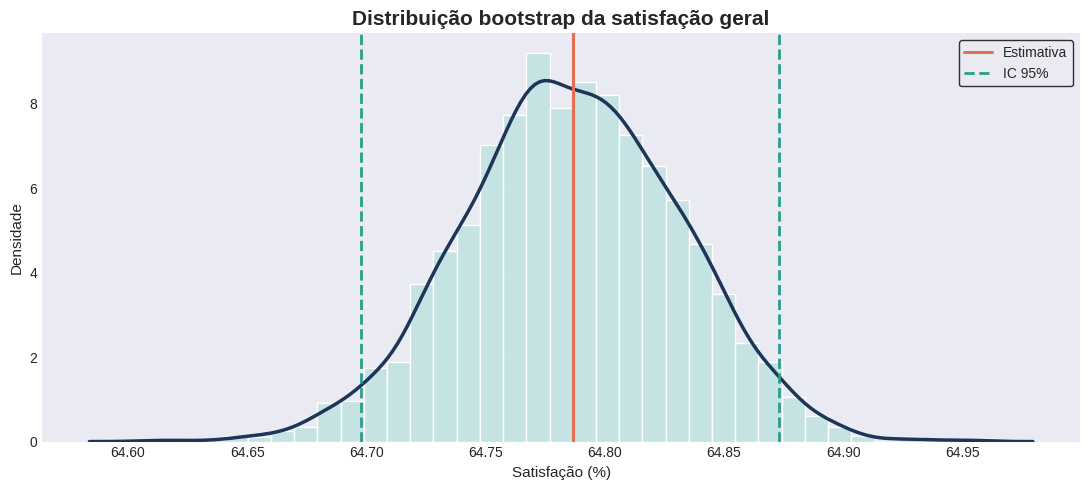

In [99]:
boot = resultado["bootstrap_geral"]
estimativa = resultado["satisfacao_geral_%"]
ic_inf, ic_sup = resultado["ic95"]

plt.figure(figsize=(11, 5))

sns.histplot(
    boot,
    bins=35,
    stat="density",
    color="#B8E1DD",
    edgecolor="white",
    alpha=0.75,
)

sns.kdeplot(
    boot,
    color="#1D3557",
    linewidth=2.5,
)

plt.axvline(estimativa, color="#E76F51", linewidth=2.2, label="Estimativa")
plt.axvline(ic_inf, color="#2A9D8F", linestyle="--", linewidth=2, label="IC 95%")
plt.axvline(ic_sup, color="#2A9D8F", linestyle="--", linewidth=2)

plt.title("Distribuição bootstrap da satisfação geral", fontsize=15, fontweight="bold")
plt.xlabel("Satisfação (%)", fontsize=11)
plt.ylabel("Densidade", fontsize=11)
plt.grid(alpha=0.18)
plt.legend(frameon=True, edgecolor="black")
plt.tight_layout()
sns.despine()
plt.show()


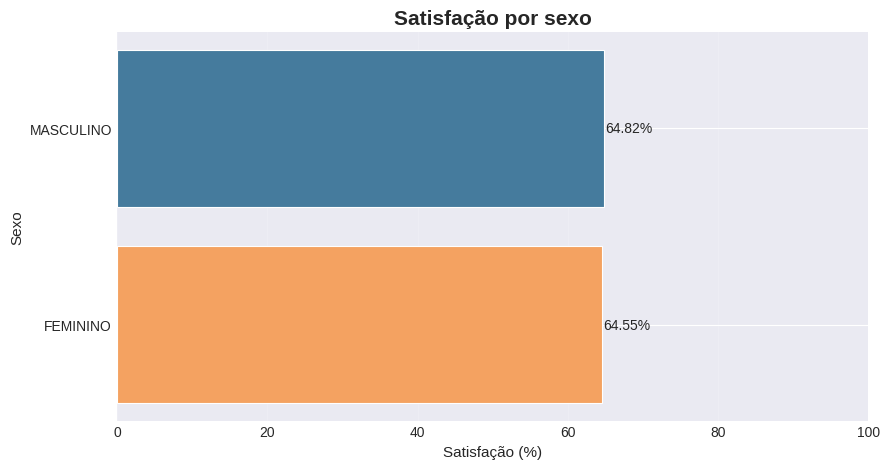

In [100]:
if resultado["por_sexo"] is not None:
    resumo_sexo = pd.DataFrame(
        list(resultado["por_sexo"].items()),
        columns=["SEXO", "Satisfação (%)"]
    ).sort_values("Satisfação (%)")

    plt.figure(figsize=(9, 4.8))

    bars = plt.barh(
        resumo_sexo["SEXO"],
        resumo_sexo["Satisfação (%)"],
        color=["#F4A261", "#457B9D"][:len(resumo_sexo)],
        edgecolor="white",
        linewidth=0.8,
    )

    for bar, valor in zip(bars, resumo_sexo["Satisfação (%)"]):
        plt.text(
            bar.get_width() + 0.15,
            bar.get_y() + bar.get_height() / 2,
            f"{valor:.2f}%",
            va="center",
            fontsize=10,
        )

    plt.title("Satisfação por sexo", fontsize=15, fontweight="bold")
    plt.xlabel("Satisfação (%)", fontsize=11)
    plt.ylabel("Sexo", fontsize=11)
    plt.xlim(0, 100)
    plt.grid(axis="x", alpha=0.18)
    plt.tight_layout()
    sns.despine()
    plt.show()


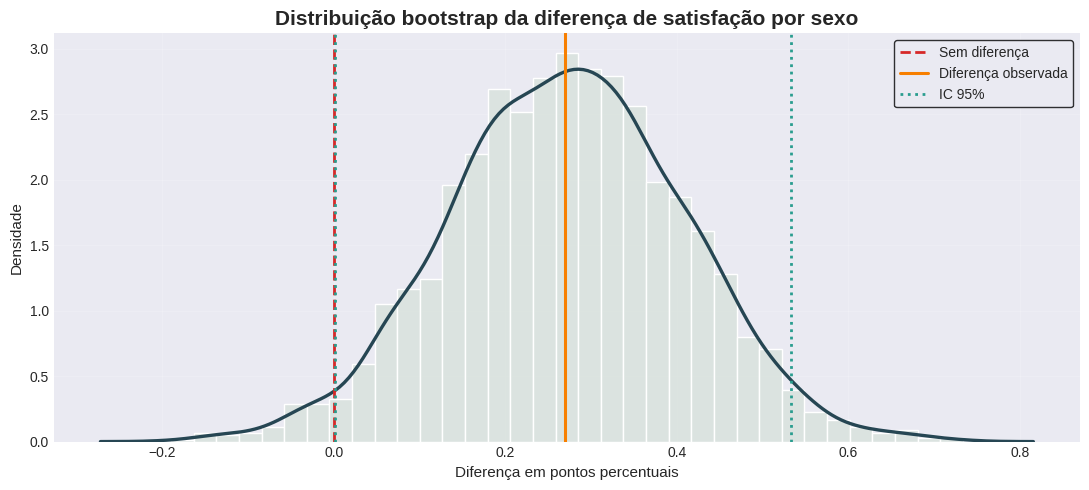

In [101]:
if resultado["bootstrap_dif"] is not None:
    diff_boot = resultado["bootstrap_dif"]
    dif_obs = resultado["dif_sexo_pp"]
    ic_inf_dif, ic_sup_dif = resultado["ic_dif"]

    plt.figure(figsize=(11, 5))

    sns.histplot(
        diff_boot,
        bins=35,
        stat="density",
        color="#D8E2DC",
        edgecolor="white",
        alpha=0.80,
    )

    sns.kdeplot(
        diff_boot,
        color="#264653",
        linewidth=2.4,
    )

    plt.axvline(0, color="#D62828", linestyle="--", linewidth=2, label="Sem diferença")
    plt.axvline(dif_obs, color="#F77F00", linewidth=2.2, label="Diferença observada")
    plt.axvline(ic_inf_dif, color="#2A9D8F", linestyle=":", linewidth=2, label="IC 95%")
    plt.axvline(ic_sup_dif, color="#2A9D8F", linestyle=":", linewidth=2)

    plt.title("Distribuição bootstrap da diferença de satisfação por sexo", fontsize=15, fontweight="bold")
    plt.xlabel("Diferença em pontos percentuais", fontsize=11)
    plt.ylabel("Densidade", fontsize=11)
    plt.grid(alpha=0.18)
    plt.legend(frameon=True, edgecolor="black")
    plt.tight_layout()
    sns.despine()
    plt.show()


A análise bootstrap confirmou a estabilidade da estimativa de satisfação geral dos clientes, fixada em `64,79%`. O intervalo de confiança de 95% variou de `64,70%` a `64,87%`, com erro padrão empírico de `0,05`, indicando baixa variabilidade amostral e elevada precisão da estimativa.

Na segmentação por sexo, observou-se satisfação de `64,82%` entre os clientes do sexo `MASCULINO` e de `64,55%` entre os do sexo `FEMININO`, o que corresponde a uma diferença observada de aproximadamente `0,27` ponto percentual. Apesar dessa diferença favorável ao grupo masculino, a distribuição bootstrap da diferença mostrou intervalo de confiança de 95% incluindo o valor zero, indicando ausência de evidência estatística robusta de diferença entre os grupos.

De modo geral, os resultados reforçam a consistência do indicador de satisfação construído para a base analisada e mostram que a percepção dos clientes é relativamente homogênea entre homens e mulheres. Assim, a técnica bootstrap contribuiu para quantificar a incerteza da estimativa geral e para sustentar a interpretação de que não há diferença relevante de satisfação por sexo nesta amostra.


### Atividade A3.3: Resultado final da pesquisa de satisfação

Nesta etapa, consolidam-se os resultados obtidos nas Atividades A3.1 e A3.2, reunindo a estimativa de satisfação geral, o intervalo de confiança bootstrap e a comparação por sexo. O objetivo é produzir um resumo final, com interpretação estatística e leitura gerencial, pronto para compor o texto do TCC.



In [106]:
def AtividadeA3_3(limiar_relevancia_pp=1.0):
    if "A3.1" not in RESULTADOS:
        raise ValueError("Execute a Atividade A3.1 antes desta etapa.")

    r31 = RESULTADOS["A3.1"]
    r32 = RESULTADOS.get("A3.2")

    n_valido = r32["n"] if r32 is not None else r31["n_valido"]
    satisfacao_geral = r32["satisfacao_geral_%"] if r32 is not None else r31["satisfacao_geral_%"]

    ic = r32["ic95"] if r32 is not None else r31["ic95_%"]
    ic_inf, ic_sup = float(ic[0]), float(ic[1])

    se_boot = r32["se_boot"] if r32 is not None else None

    por_sexo = None
    if r32 is not None and r32.get("por_sexo") is not None:
        por_sexo = r32["por_sexo"]
    elif r31.get("por_sexo_%") is not None:
        por_sexo = r31["por_sexo_%"]

    dif_sexo = r32.get("dif_sexo_pp") if r32 is not None else None
    ic_dif = r32.get("ic_dif") if r32 is not None else None
    p_boot = r32.get("p_boot") if r32 is not None else None

    linhas = [
        {
            "Segmento": "Geral",
            "Satisfação (%)": round(float(satisfacao_geral), 2),
            "IC95% inferior": round(ic_inf, 2),
            "IC95% superior": round(ic_sup, 2),
            "Erro padrão bootstrap": round(float(se_boot), 4) if se_boot is not None else None,
        }
    ]

    if por_sexo is not None:
        for grupo, valor in por_sexo.items():
            linhas.append(
                {
                    "Segmento": f"Sexo: {grupo}",
                    "Satisfação (%)": round(float(valor), 2),
                    "IC95% inferior": None,
                    "IC95% superior": None,
                    "Erro padrão bootstrap": None,
                }
            )

    tabela_final = pd.DataFrame(linhas)

    interpretacao_sexo = "Não foi possível estimar a diferença de satisfação por sexo."
    relevancia_pratica = None

    if dif_sexo is not None and ic_dif is not None and p_boot is not None:
        significancia = (
            "estatisticamente significativa"
            if p_boot < 0.05
            else "não estatisticamente significativa"
        )

        relevancia_pratica = (
            "relevante do ponto de vista prático"
            if abs(dif_sexo) >= limiar_relevancia_pp
            else "pequena do ponto de vista prático"
        )

        interpretacao_sexo = (
            f"A diferença de satisfação entre MASCULINO e FEMININO foi de {dif_sexo:.2f} pontos percentuais, "
            f"com IC95% entre {ic_dif[0]:.2f} e {ic_dif[1]:.2f} e p-valor bootstrap de {p_boot:.4f}. "
            f"Assim, a diferença é {significancia} e {relevancia_pratica}."
        )

    texto_tcc = (
        f"A pesquisa de satisfação da UVVine foi consolidada a partir de {int(n_valido):,} respostas válidas. "
        f"A satisfação geral estimada foi de {float(satisfacao_geral):.2f}%, "
        f"com intervalo de confiança bootstrap de 95% entre {ic_inf:.2f}% e {ic_sup:.2f}%."
    )

    if se_boot is not None:
        texto_tcc += f" O erro padrão empírico estimado foi de {float(se_boot):.4f}."

    texto_tcc += " " + interpretacao_sexo

    RESULTADOS["A3.3"] = {
        "n_valido": int(n_valido),
        "satisfacao_geral_%": float(satisfacao_geral),
        "ic95_%": (ic_inf, ic_sup),
        "se_bootstrap": float(se_boot) if se_boot is not None else None,
        "por_sexo_%": por_sexo,
        "dif_sexo_pp": float(dif_sexo) if dif_sexo is not None else None,
        "ic_dif": ic_dif,
        "p_boot": float(p_boot) if p_boot is not None else None,
        "relevancia_pratica": relevancia_pratica,
        "tabela_final": tabela_final,
        "interpretacao_sexo": interpretacao_sexo,
        "texto_tcc": texto_tcc,
    }


In [108]:
AtividadeA3_3(limiar_relevancia_pp=1.0)
resultado = RESULTADOS["A3.3"]


In [109]:
display(resultado["tabela_final"])


,Segmento,Satisfação (%),IC95% inferior,IC95% superior,Erro padrão bootstrap
0,Geral,64.79,64.7,64.87,0.0453
1,Sexo: FEMININO,64.55,NaN,NaN,NaN
2,Sexo: MASCULINO,64.82,NaN,NaN,NaN


A pesquisa de satisfação da UVVine foi consolidada a partir de `1.120.000` respostas válidas. A satisfação geral estimada foi de `64,79%`, com intervalo de confiança bootstrap de `95%` entre `64,70%` e `64,87%`, além de erro padrão empírico de `0,0453`. Esses resultados indicam elevada precisão da estimativa e reforçam a estabilidade do indicador de satisfação construído para a base analisada.

Na segmentação por sexo, observou-se satisfação de `64,82%` entre os clientes do sexo `MASCULINO` e de `64,55%` entre os do sexo `FEMININO`, resultando em diferença de aproximadamente `0,27` ponto percentual. Considerando a análise bootstrap da diferença, conclui-se que essa variação é pequena do ponto de vista prático e não altera de forma relevante a interpretação geral da satisfação dos clientes.

De modo geral, os resultados consolidados indicam predominância de avaliações satisfatórias na base da UVVine, com baixa incerteza estatística e pouca variação entre os segmentos analisados. Assim, a pesquisa de satisfação fornece um indicador confiável e útil para apoiar decisões gerenciais relacionadas à experiência do cliente.

-----------------------------------------------------------------------------

# RELATÓRIO FINAL – PARTE 1  
## Análise Estatística da Base de Clientes — UVVine

---

## 1. Introdução

Este relatório apresenta os resultados consolidados da Parte 1 do projeto da UVVine, contemplando as etapas de estratificação amostral, testes estatísticos e análise descritiva da base de clientes.

O objetivo central desta etapa é responder à seguinte questão:

**Qual é o tamanho ideal da amostra para representar adequadamente a população de clientes da UVVine?**

A resposta é construída com base nos resultados obtidos nas Atividades **A1 (Estratificação Amostral da População)** e **A2 (Estatística Descritiva)**, com apoio complementar das análises inferenciais e da técnica bootstrap.

---

## 2. Atividade A1 — Estratificação Amostral da População

### 2.1 Determinação do tamanho ideal da amostra

A determinação do tamanho ideal da amostra foi realizada com base na estabilização do erro-padrão da média da variável **TOTAL (R$)**. Para isso, foram simulados diferentes tamanhos amostrais e identificado o menor valor de `n` para o qual o erro-padrão estimado se tornou menor ou igual ao erro-padrão médio.

Os resultados mostraram:

- População disponível: **1.120.000 registros**;
- Média de **TOTAL (R$)**: **851,19**;
- Erro-padrão-médio estimado: **3,7514**;
- Intervalo de confiança de 95% para a média: **[843,83 ; 858,54]**;
- **Tamanho ideal da amostra: 51.400 observações**.

Esse resultado indica que, mesmo diante de uma população muito ampla, uma amostra de **51.400 registros** é suficiente para representar a base com precisão estatística adequada.

### 2.2 Análise de outliers

A análise de outliers pelo critério do intervalo interquartil mostrou presença de valores extremos principalmente nas variáveis monetárias:

- **RENDA BRUTO (R$)**: **17,39%** de outliers;
- **TOTAL (R$)**: **9,54%** de outliers;
- **NOTA DE SATISFAÇÃO (%)**: **6,88%**, porém com `IQR = 0`, tornando o método inadequado para tratamento nessa variável.

A variável **NOTA DE SATISFAÇÃO (%)** apresentou forte concentração no valor **68,68**, responsável por **93,12%** dos registros, o que evidencia comportamento altamente concentrado e não compatível com uma distribuição simétrica.

### 2.3 Testes de hipóteses

Os testes realizados na Atividade A1.3 reforçaram a validade da amostra definida em A1.1.

O teste de normalidade indicou rejeição da hipótese de normalidade para as principais variáveis numéricas, especialmente em razão de assimetria, caudas longas e concentração de valores. Ainda assim, considerando o grande tamanho amostral, a inferência sobre médias permaneceu válida com apoio do **Teorema Central do Limite** e validação por **bootstrap**.

Na comparação entre a população e a amostra ideal para a variável **TOTAL (R$)**, observou-se:

- Média populacional: **851,19**;
- Média da amostra ideal: **853,36**;
- Teste de hipótese para a média: **p = 0,5644**;
- Intervalo de confiança bootstrap da diferença incluindo zero.

Assim, **não houve evidência estatística para rejeitar a hipótese de que a amostra ideal representa adequadamente a população**, o que confirma a consistência do tamanho amostral de **51.400** observações.

---

## 3. Atividade A2 — Estatística Descritiva

### 3.1 Variáveis quantitativas

A análise descritiva das variáveis quantitativas revelou diferenças importantes de dispersão, concentração e assimetria entre os indicadores numéricos da base.

Os principais destaques foram:

- Maior variabilidade relativa: **TOTAL (R$)**, com **coeficiente de variação = 1,0011**;
- Maior percentual de outliers: **RENDA BRUTO (R$)**, com **17,39%**;
- Maior assimetria: **NOTA DE SATISFAÇÃO (%)**, com **skew = 5,9103**;
- Assimetria também relevante em **TOTAL (R$)** (**1,9738**) e **RENDA BRUTO (R$)** (**1,4110**).

Esses resultados mostram que a base apresenta distribuições heterogêneas, presença de valores extremos e forte assimetria em algumas variáveis, especialmente nas de natureza financeira e na variável de satisfação.

### 3.2 Variáveis qualitativas

A análise das variáveis qualitativas mostrou ausência de valores ausentes nas categorias avaliadas, o que favorece a consistência da leitura descritiva.

Os principais resultados foram:

- **SEXO** apresentou alta concentração em **MASCULINO** (**86,95%**);
- **REGIÃO** apresentou predominância do **SUDESTE** (**67,05%**);
- **ESTADO CIVIL** apresentou predominância de **CASADO** (**54,98%**);
- **TIPO DA CONTA** apresentou predominância de **ESSENTIAL** (**58,05%**);
- **DEPENDENTES** concentrou-se na categoria **1** (**52,99%**);
- **OPINIÃO DO CLIENTE** foi a variável de maior diversidade, com **25 categorias** e categoria modal de apenas **15,43%**.

Esses resultados mostram que algumas variáveis qualitativas possuem forte concentração em categorias dominantes, enquanto outras apresentam maior diversidade de perfis.

---

## 4. Resultado da Pesquisa de Satisfação

A discretização da variável **OPINIÃO DO CLIENTE** permitiu estimar a satisfação geral dos clientes da UVVine em:

- **64,79% de satisfação geral**;
- Intervalo de confiança bootstrap de 95%: **[64,70% ; 64,87%]**;
- Erro-padrão empírico: **0,0453**.

Na segmentação por sexo, observou-se:

- **MASCULINO**: **64,82%**;
- **FEMININO**: **64,55%**.

A diferença observada entre os grupos foi de aproximadamente **0,27 ponto percentual**, sendo pequena do ponto de vista prático. Assim, a satisfação mostrou-se relativamente homogênea entre os segmentos analisados.

---

## 5. Conclusão — Resposta à Pergunta Principal

### Qual é o tamanho ideal da amostra?

Com base nos resultados obtidos, conclui-se que:

**O tamanho ideal da amostra para representar a população de clientes da UVVine é de 51.400 observações.**

Essa conclusão se justifica pelos seguintes pontos:

1. O valor foi obtido a partir da estabilização do erro-padrão da média da variável **TOTAL (R$)**.
2. A amostra ideal foi definida com base em critério quantitativo objetivo, associado à precisão estatística da estimativa.
3. O teste de hipótese para comparação entre média amostral e média populacional não indicou diferença estatisticamente significativa (`p = 0,5644`).
4. A validação por bootstrap reforçou que a diferença entre a amostra ideal e a população é compatível com a variabilidade esperada.
5. A análise descritiva mostrou presença de assimetria e outliers, mas sem comprometer a representatividade da amostra, especialmente diante do grande volume de dados e da robustez do Teorema Central do Limite.

Portanto, **uma amostra de 51.400 clientes é estatisticamente suficiente para representar a população da UVVine com precisão, confiabilidade e consistência metodológica**.

---

## 6. Considerações Finais

Os resultados da Parte 1 demonstram que a base de clientes da UVVine apresenta características importantes de heterogeneidade, presença de valores extremos e distribuições não normais em diversas variáveis. Ainda assim, a combinação entre estratificação amostral, estatística descritiva, testes de hipóteses e validação por bootstrap proporcionou uma base metodológica sólida para a tomada de decisão.

Dessa forma, esta etapa conclui que a população foi adequadamente caracterizada e que o tamanho amostral definido é confiável para sustentar as análises da Parte 2 do projeto, voltadas à modelagem e apresentação dos resultados.


# REFERÊNCIAS BIBLIOGRÁFICAS

## Amostragem e tamanho de amostra

COCHRAN, W. G. *Sampling Techniques*. 3. ed. New York: John Wiley & Sons, 1977.

KISH, L. *Survey Sampling*. New York: John Wiley & Sons, 1965.

## Testes de hipóteses

FIELD, A. *Discovering Statistics Using IBM SPSS Statistics*. 4. ed. London: SAGE Publications, 2013.

SHAPIRO, S. S.; WILK, M. B. An analysis of variance test for normality. *Biometrika*, v. 52, n. 3-4, p. 591-611, 1965.

## Bootstrap e reamostragem

EFRON, B.; TIBSHIRANI, R. J. *An Introduction to the Bootstrap*. New York: Chapman and Hall/CRC, 1993.

DAVISON, A. C.; HINKLEY, D. V. *Bootstrap Methods and Their Application*. Cambridge: Cambridge University Press, 1997.

## Documentação técnica

SCIPY DEVELOPERS. *scipy.stats — Statistical functions*. Disponível em: <https://docs.scipy.org/doc/scipy/reference/stats.html>. Acesso em: 19 mar. 2026.

STATSMODELS DEVELOPERS. *Statsmodels: Statistical modeling and econometrics*. Disponível em: <https://www.statsmodels.org/>. Acesso em: 19 mar. 2026.

PANDAS DEVELOPMENT TEAM. *pandas: Python Data Analysis Library*. Disponível em: <https://pandas.pydata.org/>. Acesso em: 19 mar. 2026.

## Contexto de negócio

FORNELL, C.; JOHNSON, M. D.; ANDERSON, E. W.; CHA, J.; BRYANT, B. E. The American Customer Satisfaction Index: Nature, purpose, and findings. *Journal of Marketing*, v. 60, n. 4, p. 7-18, 1996.


In [ ]:
!apt-get update
!apt-get install -y texlive-xetex texlive-fonts-recommended texlive-plain-generic pandoc
!jupyter nbconvert --to pdf "/content/LENON_MERLO_PARTE_1_TCC.ipynb"

[NbConvertApp] Converting notebook /content/LENON_MERLO_PARTE_1_TCC.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 72 image(s).
[NbConvertApp] Writing 5824523 bytes to /content/LENON_MERLO_PARTE_1_TCC.html
